## PRCP-1008: NBA Shot Selection

## Introduction

Basketball has increasingly adopted data analytics to support tactical and strategic
decision-making. Shot selection is particularly important because the probability of
scoring depends on several factors such as shot distance, shot type, court location,
time remaining, game period, opponent, and the type of action performed by the player.

This project analyzes field-goal attempts made by Kobe Bryant during his NBA career.
The objective is to understand the circumstances associated with successful and
unsuccessful shots and develop machine learning models capable of predicting whether
a shot will be made or missed.

The project combines exploratory data analysis, feature engineering, preprocessing,
machine learning, model evaluation, and model comparison. Accuracy and F1-score are
used as important evaluation metrics to identify the most suitable model.

## Business Understanding

Shot selection plays an important role in basketball strategy. Coaches and analysts
need to understand which shooting situations provide a higher probability of success.

By analyzing historical shot attempts, machine learning can help identify patterns
related to shot success.

The results of this project can help stakeholders:

- Understand which types of shots are more successful.
- Identify favorable and unfavorable shooting locations.
- Study the influence of shot distance.
- Analyze shooting performance during different game periods.
- Examine performance against different opponents.
- Develop more effective offensive strategies.
- Predict the probability that a future shot will be successful.

## Problem Statement

The objective of this project is to build a machine learning classification model
that predicts whether a basketball shot will be made or missed based on the
circumstances under which the shot was attempted.

The target variable is `shot_made_flag`.

- 1 represents a successful shot.
- 0 represents a missed shot.

Multiple machine learning algorithms will be trained and evaluated. Their performance
will be compared using evaluation metrics such as Accuracy, Precision, Recall and
F1-score, and the best-performing model will be recommended for production.

## Type of Machine Learning Problem

This project is a supervised binary classification problem.

It is supervised because historical shot attempts contain known outcomes that can be
used to train the model.

It is binary classification because the target variable has two possible outcomes:

| shot_made_flag | Meaning |
|---|---|
| 0 | Shot Missed |
| 1 | Shot Made |

## Dataset Description

The dataset contains information about field-goal attempts made by Kobe Bryant during
his NBA career.

Each row represents one shot attempt.

The dataset contains information about:

- Type of shot
- Court location
- Shot distance
- Game period
- Time remaining
- Opponent
- Season
- Playoff status
- Shot zone
- Shot outcome

The target variable is `shot_made_flag`.

| Feature | Description |
|---|---|
| action_type | Specific basketball action used for the shot |
| combined_shot_type | General category of shot |
| game_event_id | Identifier of the event within a game |
| game_id | Unique game identifier |
| lat | Latitude-based shot location |
| loc_x | Horizontal court location |
| loc_y | Vertical court location |
| lon | Longitude-based shot location |
| minutes_remaining | Minutes remaining in the period |
| period | Game period/quarter |
| playoffs | Whether the game was a playoff game |
| season | NBA season |
| seconds_remaining | Seconds remaining in the minute |
| shot_distance | Distance of the shot |
| shot_made_flag | Target: made or missed |
| shot_type | 2-point or 3-point field goal |
| shot_zone_area | Area of the basketball court |
| shot_zone_basic | General shot zone |
| shot_zone_range | Distance-based shot zone |
| team_id | Team identifier |
| team_name | Team name |
| game_date | Date of the game |
| matchup | Matchup information |
| opponent | Opposing team |
| shot_id | Unique identifier for each shot |

## Import libraries

In [220]:
# Numerical operations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test splitting
from sklearn.model_selection import train_test_split

# Data preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [221]:
df = pd.read_csv("data.csv")

df.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


In [222]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 30697
Number of Columns: 25


In [223]:
print(df.columns.tolist())

['action_type', 'combined_shot_type', 'game_event_id', 'game_id', 'lat', 'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs', 'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag', 'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'team_id', 'team_name', 'game_date', 'matchup', 'opponent', 'shot_id']


In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [225]:
df.dtypes

action_type            object
combined_shot_type     object
game_event_id           int64
game_id                 int64
lat                   float64
loc_x                   int64
loc_y                   int64
lon                   float64
minutes_remaining       int64
period                  int64
playoffs                int64
season                 object
seconds_remaining       int64
shot_distance           int64
shot_made_flag        float64
shot_type              object
shot_zone_area         object
shot_zone_basic        object
shot_zone_range        object
team_id                 int64
team_name              object
game_date              object
matchup                object
opponent               object
shot_id                 int64
dtype: object

In [226]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

shot_made_flag    5000
dtype: int64

In [227]:
# Data where shot outcome is known
model_data = df[df["shot_made_flag"].notnull()].copy()

# Data where shot outcome is unknown
unknown_shots = df[df["shot_made_flag"].isnull()].copy()

print("Rows available for model training:", model_data.shape[0])
print("Rows with unknown shot outcome:", unknown_shots.shape[0])

Rows available for model training: 25697
Rows with unknown shot outcome: 5000


In [228]:
model_data["shot_made_flag"] = model_data["shot_made_flag"].astype(int)

In [229]:
print(model_data["shot_made_flag"].dtype)

print(model_data["shot_made_flag"].unique())

int32
[0 1]


In [230]:
model_data.describe().T

,count,mean,std,min,25%,50%,75%,max
game_event_id,25697.0,2.493487e+02,1.497785e+02,2.000000e+00,1.110000e+02,2.530000e+02,3.670000e+02,6.530000e+02
game_id,25697.0,2.474109e+07,7.738108e+06,2.000001e+07,2.050006e+07,2.090034e+07,2.960027e+07,4.990009e+07
lat,25697.0,3.395304e+01,8.815211e-02,3.325330e+01,3.388430e+01,3.397030e+01,3.404030e+01,3.408830e+01
loc_x,25697.0,7.148422e+00,1.100731e+02,-2.500000e+02,-6.700000e+01,0.000000e+00,9.400000e+01,2.480000e+02
loc_y,25697.0,9.125735e+01,8.815211e+01,-4.400000e+01,4.000000e+00,7.400000e+01,1.600000e+02,7.910000e+02
lon,25697.0,-1.182627e+02,1.100731e-01,-1.185198e+02,-1.183368e+02,-1.182698e+02,-1.181758e+02,-1.180218e+02
minutes_remaining,25697.0,4.886796e+00,3.452475e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
period,25697.0,2.520800e+00,1.151626e+00,1.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00,7.000000e+00
playoffs,25697.0,1.462428e-01,3.533563e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
seconds_remaining,25697.0,2.831155e+01,1.752339e+01,0.000000e+00,1.300000e+01,2.800000e+01,4.300000e+01,5.900000e+01


In [231]:
duplicates = model_data.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is the process of examining and visualizing a dataset
before building a machine learning model.

The purpose of EDA is to understand the structure of the data, identify patterns,
detect unusual observations, study relationships between variables, and discover
which factors may influence the target variable.

In this NBA Shot Selection project, EDA is particularly important because we want
to understand the circumstances under which Kobe Bryant was more or less likely
to make a shot.

The analysis focuses on factors such as:

- Shot outcome
- Shot distance
- Shot type
- Action type
- Court location
- Shot zone
- Game period
- Time remaining
- Playoff status
- Season
- Opponent

The insights obtained from EDA will later guide feature engineering, feature
selection, preprocessing, and model development.

In [234]:
model_data = df[df["shot_made_flag"].notnull()].copy()
unknown_shots = df[df["shot_made_flag"].isnull()].copy()

model_data["shot_made_flag"] = model_data["shot_made_flag"].astype(int)

In [235]:
print("Original Dataset Shape:", df.shape)
print("Modeling Dataset Shape:", model_data.shape)
print("Unknown Shot Dataset Shape:", unknown_shots.shape)

print("\nTarget Values:")
print(model_data["shot_made_flag"].unique())

Original Dataset Shape: (30697, 25)
Modeling Dataset Shape: (25697, 25)
Unknown Shot Dataset Shape: (5000, 25)

Target Values:
[0 1]


In [236]:
shot_counts = model_data["shot_made_flag"].value_counts().sort_index()

print("Shot Outcome Counts:")
print(shot_counts)

shot_percentages = (
    model_data["shot_made_flag"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nShot Outcome Percentages:")
print(shot_percentages.round(2))

Shot Outcome Counts:
shot_made_flag
0    14232
1    11465
Name: count, dtype: int64

Shot Outcome Percentages:
shot_made_flag
0    55.38
1    44.62
Name: proportion, dtype: float64


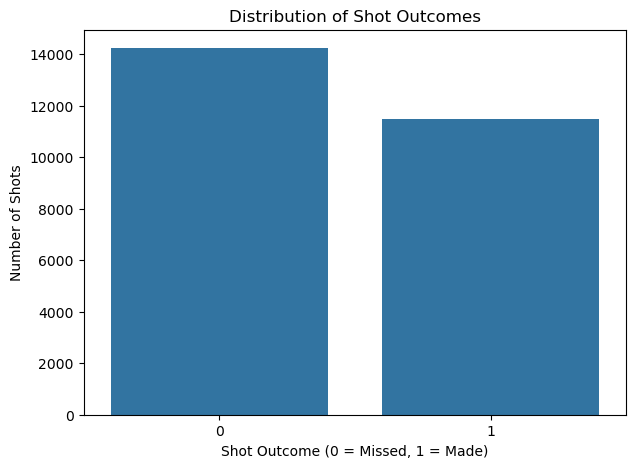

In [237]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=model_data,
    x="shot_made_flag"
)

plt.title("Distribution of Shot Outcomes")
plt.xlabel("Shot Outcome (0 = Missed, 1 = Made)")
plt.ylabel("Number of Shots")

plt.show()

In [238]:
print(model_data["combined_shot_type"].value_counts())

combined_shot_type
Jump Shot    19710
Layup         4532
Dunk          1056
Tip Shot       152
Hook Shot      127
Bank Shot      120
Name: count, dtype: int64


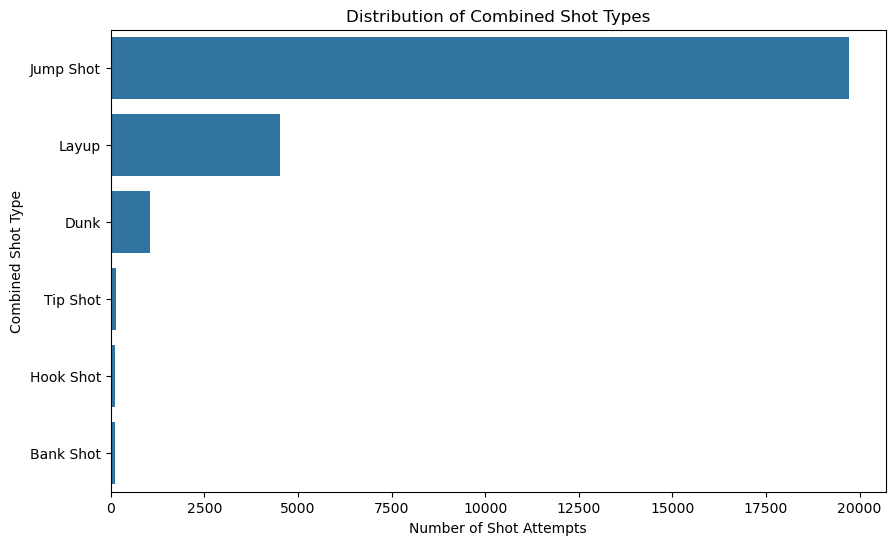

In [239]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=model_data,
    y="combined_shot_type",
    order=model_data["combined_shot_type"].value_counts().index
)

plt.title("Distribution of Combined Shot Types")
plt.xlabel("Number of Shot Attempts")
plt.ylabel("Combined Shot Type")

plt.show()

In [240]:
shot_type_success = (
    model_data.groupby("combined_shot_type")["shot_made_flag"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

shot_type_success["success_rate"] = shot_type_success["mean"] * 100

shot_type_success

,count,mean,success_rate
combined_shot_type,,,
Dunk,1056,0.928030,92.803030
Bank Shot,120,0.791667,79.166667
Layup,4532,0.565093,56.509267
Hook Shot,127,0.535433,53.543307
Jump Shot,19710,0.391071,39.107052
Tip Shot,152,0.348684,34.868421


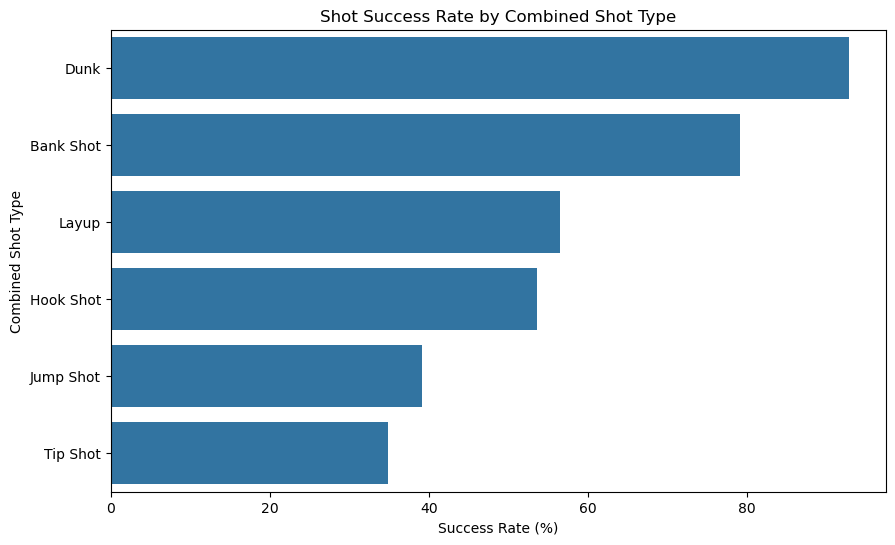

In [241]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=shot_type_success.reset_index(),
    x="success_rate",
    y="combined_shot_type"
)

plt.title("Shot Success Rate by Combined Shot Type")
plt.xlabel("Success Rate (%)")
plt.ylabel("Combined Shot Type")

plt.show()

In [242]:
print("Number of Unique Action Types:")
print(model_data["action_type"].nunique())

print("\nTop 15 Action Types:")
print(model_data["action_type"].value_counts().head(15))

Number of Unique Action Types:
55

Top 15 Action Types:
action_type
Jump Shot                   15836
Layup Shot                   2154
Driving Layup Shot           1628
Turnaround Jump Shot          891
Fadeaway Jump Shot            872
Running Jump Shot             779
Pullup Jump shot              402
Turnaround Fadeaway shot      366
Slam Dunk Shot                334
Reverse Layup Shot            333
Jump Bank Shot                289
Driving Dunk Shot             257
Dunk Shot                     217
Tip Shot                      151
Step Back Jump shot           106
Name: count, dtype: int64


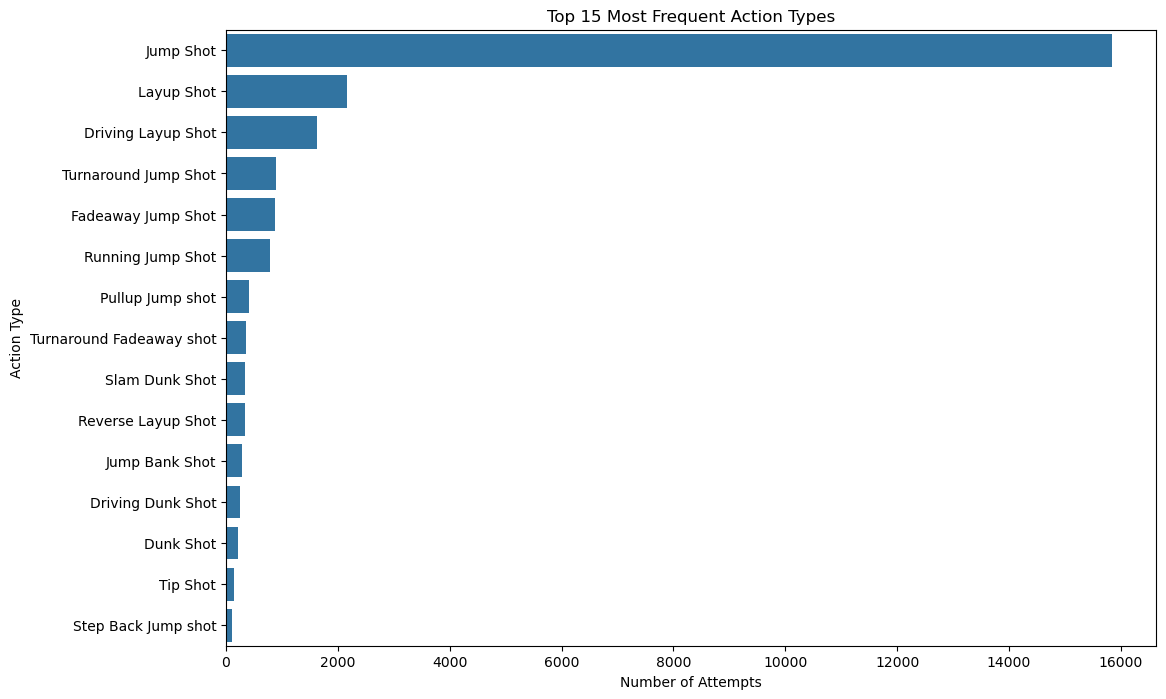

In [243]:
top_actions = model_data["action_type"].value_counts().head(15).index

plt.figure(figsize=(12, 8))

sns.countplot(
    data=model_data[model_data["action_type"].isin(top_actions)],
    y="action_type",
    order=top_actions
)

plt.title("Top 15 Most Frequent Action Types")
plt.xlabel("Number of Attempts")
plt.ylabel("Action Type")

plt.show()

In [244]:
model_data["shot_distance"].describe()

count    25697.000000
mean        13.457096
std          9.388725
min          0.000000
25%          5.000000
50%         15.000000
75%         21.000000
max         79.000000
Name: shot_distance, dtype: float64

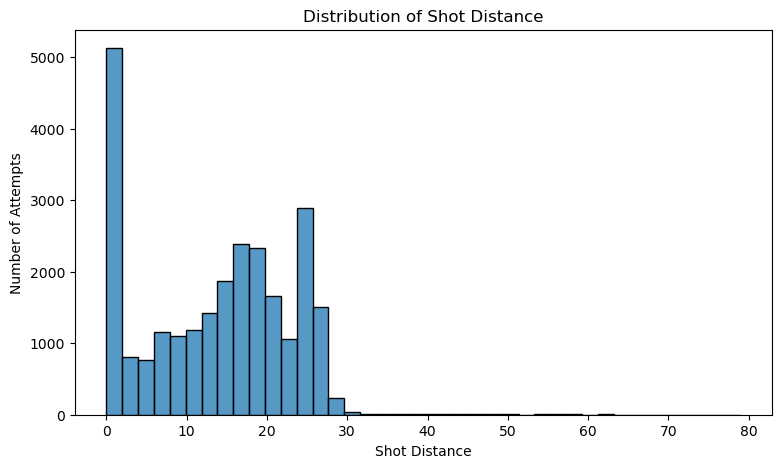

In [245]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=model_data,
    x="shot_distance",
    bins=40
)

plt.title("Distribution of Shot Distance")
plt.xlabel("Shot Distance")
plt.ylabel("Number of Attempts")

plt.show()

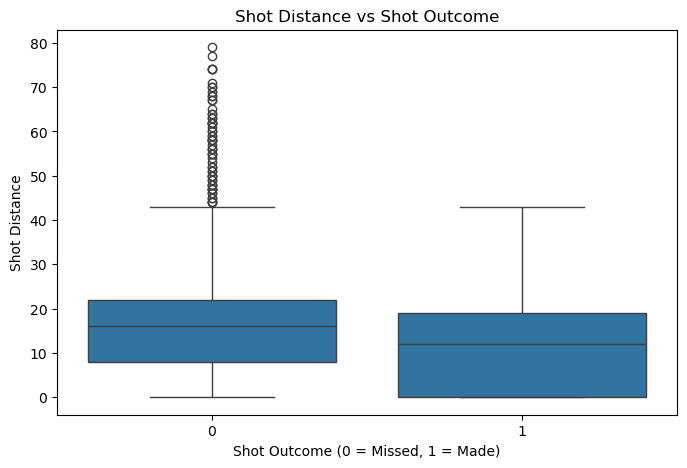

In [246]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_data,
    x="shot_made_flag",
    y="shot_distance"
)

plt.title("Shot Distance vs Shot Outcome")
plt.xlabel("Shot Outcome (0 = Missed, 1 = Made)")
plt.ylabel("Shot Distance")

plt.show()

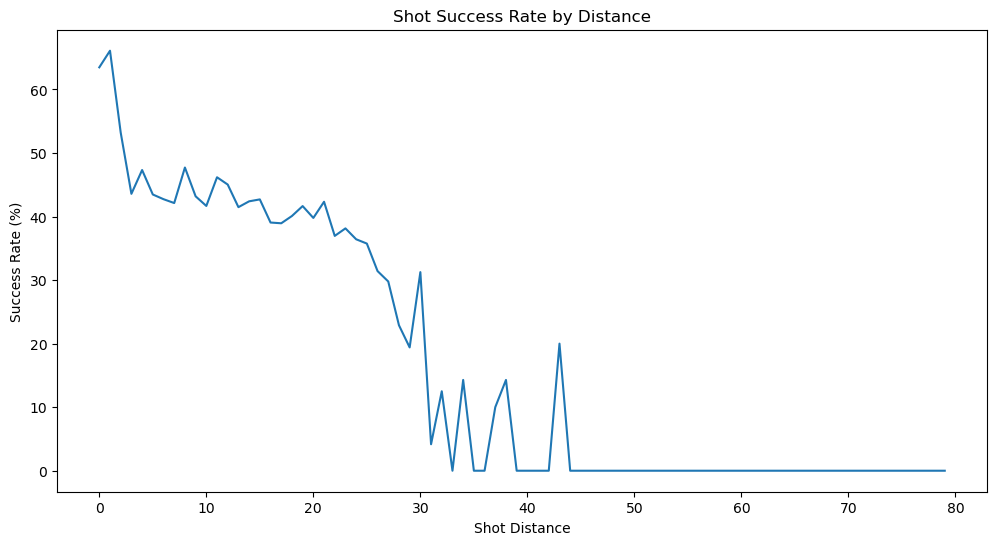

In [247]:
distance_success = (
    model_data.groupby("shot_distance")["shot_made_flag"]
    .mean()
    .reset_index()
)

distance_success["success_rate"] = (
    distance_success["shot_made_flag"] * 100
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=distance_success,
    x="shot_distance",
    y="success_rate"
)

plt.title("Shot Success Rate by Distance")
plt.xlabel("Shot Distance")
plt.ylabel("Success Rate (%)")

plt.show()

In [248]:
print(model_data["shot_type"].value_counts())

shot_type
2PT Field Goal    20285
3PT Field Goal     5412
Name: count, dtype: int64


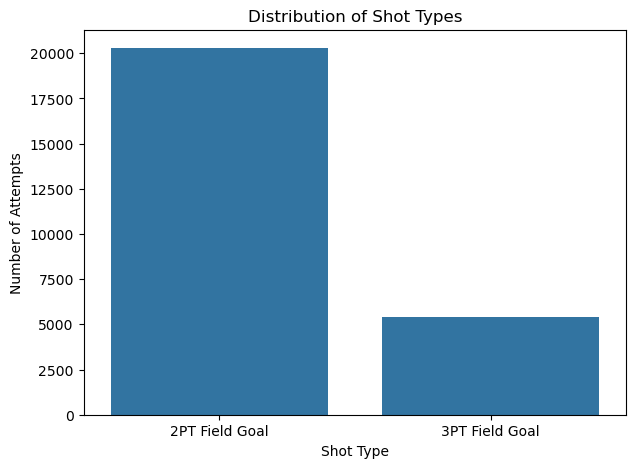

In [249]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=model_data,
    x="shot_type"
)

plt.title("Distribution of Shot Types")
plt.xlabel("Shot Type")
plt.ylabel("Number of Attempts")

plt.show()

In [250]:
shot_type_rate = (
    model_data.groupby("shot_type")["shot_made_flag"]
    .mean()
    .mul(100)
    .reset_index(name="success_rate")
)

shot_type_rate

,shot_type,success_rate
0,2PT Field Goal,47.734779
1,3PT Field Goal,32.926829


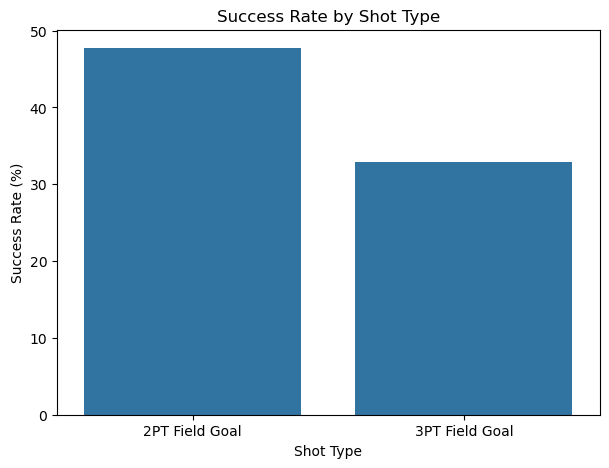

In [251]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=shot_type_rate,
    x="shot_type",
    y="success_rate"
)

plt.title("Success Rate by Shot Type")
plt.xlabel("Shot Type")
plt.ylabel("Success Rate (%)")

plt.show()

In [252]:
print(model_data["shot_zone_basic"].value_counts())

shot_zone_basic
Mid-Range                10532
Restricted Area           5932
Above the Break 3         4720
In The Paint (Non-RA)     3880
Right Corner 3             333
Left Corner 3              240
Backcourt                   60
Name: count, dtype: int64


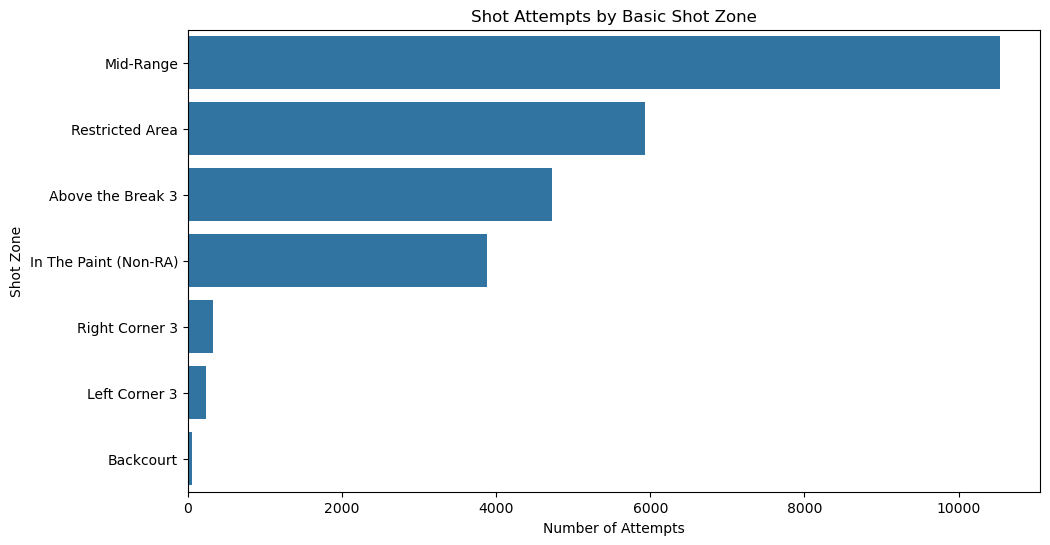

In [253]:
plt.figure(figsize=(11, 6))

sns.countplot(
    data=model_data,
    y="shot_zone_basic",
    order=model_data["shot_zone_basic"].value_counts().index
)

plt.title("Shot Attempts by Basic Shot Zone")
plt.xlabel("Number of Attempts")
plt.ylabel("Shot Zone")

plt.show()

In [254]:
zone_success = (
    model_data.groupby("shot_zone_basic")["shot_made_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="success_rate")
)

zone_success

,shot_zone_basic,success_rate
0,Restricted Area,61.800405
1,In The Paint (Non-RA),45.438144
2,Mid-Range,40.628561
3,Left Corner 3,37.083333
4,Right Corner 3,33.933934
5,Above the Break 3,32.923729
6,Backcourt,1.666667


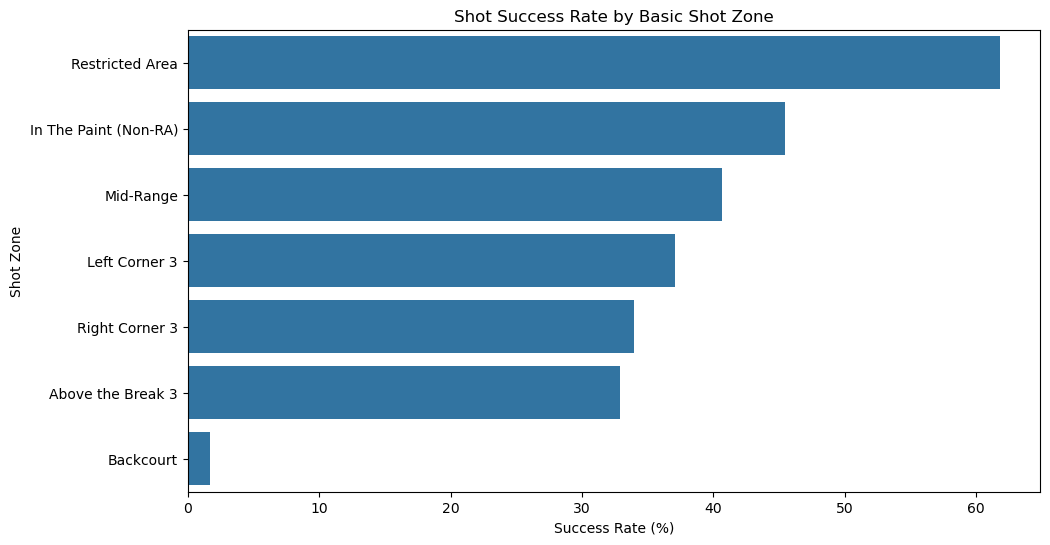

In [255]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=zone_success,
    x="success_rate",
    y="shot_zone_basic"
)

plt.title("Shot Success Rate by Basic Shot Zone")
plt.xlabel("Success Rate (%)")
plt.ylabel("Shot Zone")

plt.show()

In [256]:
area_success = (
    model_data.groupby("shot_zone_area")["shot_made_flag"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

area_success["success_rate"] = area_success["mean"] * 100

area_success

,count,mean,success_rate
shot_zone_area,,,
Center(C),11289,0.525556,52.555585
Right Side(R),3859,0.401658,40.165846
Left Side(L),3132,0.396871,39.687101
Right Side Center(RC),3981,0.382567,38.256719
Left Side Center(LC),3364,0.361177,36.117717
Back Court(BC),72,0.013889,1.388889


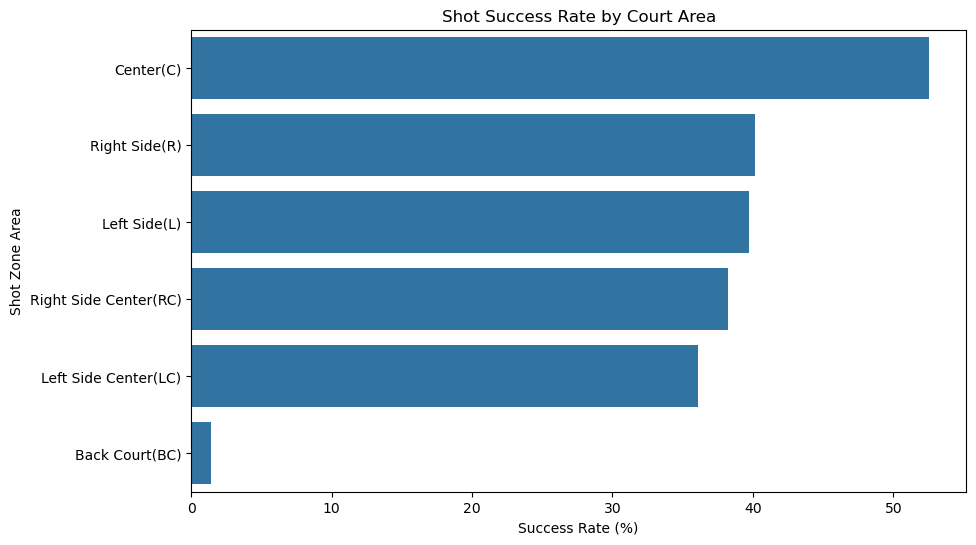

In [257]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=area_success.reset_index(),
    x="success_rate",
    y="shot_zone_area"
)

plt.title("Shot Success Rate by Court Area")
plt.xlabel("Success Rate (%)")
plt.ylabel("Shot Zone Area")

plt.show()

In [258]:
range_success = (
    model_data.groupby("shot_zone_range")["shot_made_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="success_rate")
)

range_success

,shot_zone_range,success_rate
0,Less Than 8 ft.,57.311951
1,8-16 ft.,43.548387
2,16-24 ft.,40.176632
3,24+ ft.,33.251278
4,Back Court Shot,1.388889


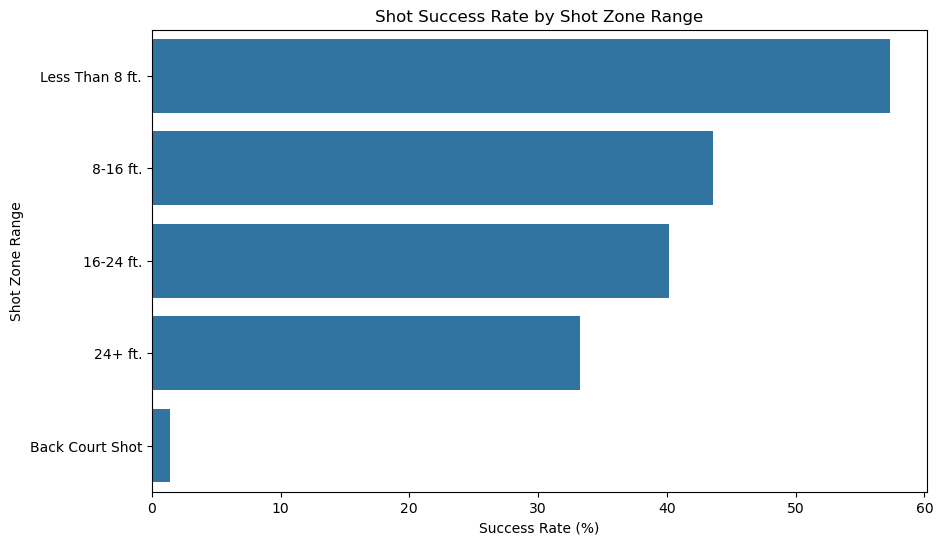

In [259]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=range_success,
    x="success_rate",
    y="shot_zone_range"
)

plt.title("Shot Success Rate by Shot Zone Range")
plt.xlabel("Success Rate (%)")
plt.ylabel("Shot Zone Range")

plt.show()

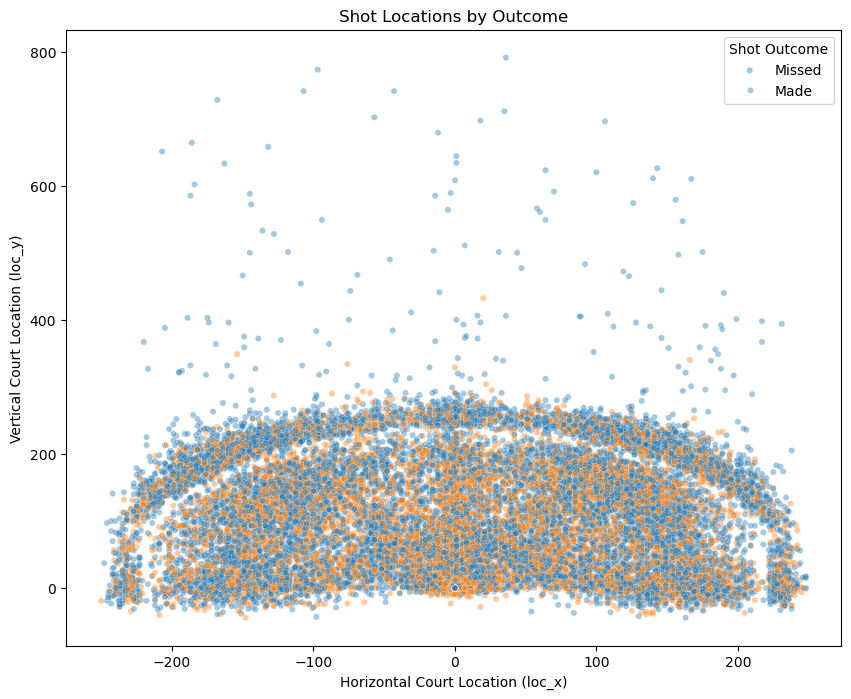

In [260]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=model_data,
    x="loc_x",
    y="loc_y",
    hue="shot_made_flag",
    alpha=0.4,
    s=20
)

plt.title("Shot Locations by Outcome")
plt.xlabel("Horizontal Court Location (loc_x)")
plt.ylabel("Vertical Court Location (loc_y)")

plt.legend(
    title="Shot Outcome",
    labels=["Missed", "Made"]
)

plt.show()

In [261]:
print(model_data["period"].value_counts().sort_index())

period
1    6700
2    5635
3    7002
4    6043
5     280
6      30
7       7
Name: count, dtype: int64


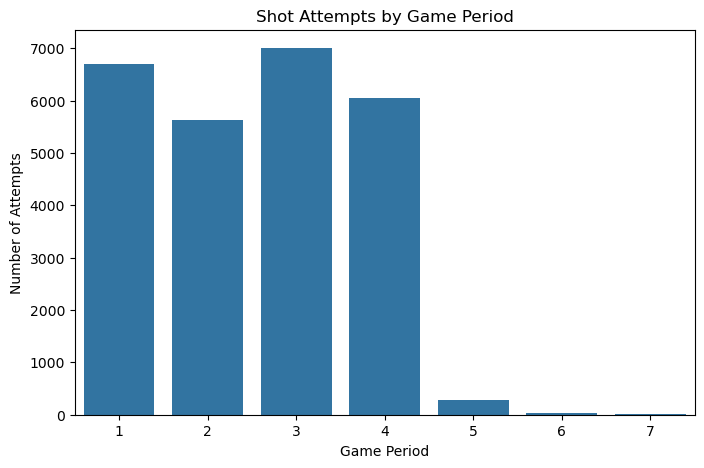

In [262]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=model_data,
    x="period"
)

plt.title("Shot Attempts by Game Period")
plt.xlabel("Game Period")
plt.ylabel("Number of Attempts")

plt.show()

In [263]:
period_success = (
    model_data.groupby("period")["shot_made_flag"]
    .mean()
    .mul(100)
    .reset_index(name="success_rate")
)

period_success

,period,success_rate
0,1,46.567164
1,2,44.880213
2,3,45.344187
3,4,41.370180
4,5,44.285714
5,6,46.666667
6,7,42.857143


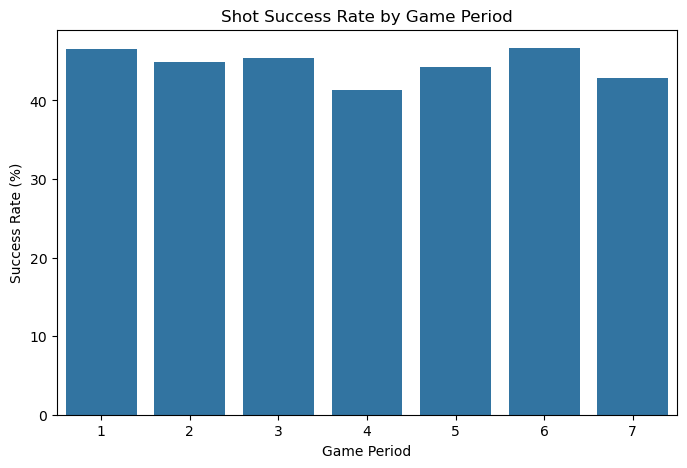

In [264]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=period_success,
    x="period",
    y="success_rate"
)

plt.title("Shot Success Rate by Game Period")
plt.xlabel("Game Period")
plt.ylabel("Success Rate (%)")

plt.show()

In [265]:
model_data["seconds_remaining_in_period"] = (
    model_data["minutes_remaining"] * 60
    + model_data["seconds_remaining"]
)

In [266]:
model_data[
    [
        "minutes_remaining",
        "seconds_remaining",
        "seconds_remaining_in_period"
    ]
].head()

,minutes_remaining,seconds_remaining,seconds_remaining_in_period
1,10,22,622
2,7,45,465
3,6,52,412
4,6,19,379
5,9,32,572


In [267]:
model_data["time_remaining_group"] = pd.cut(
    model_data["seconds_remaining_in_period"],
    bins=[-1, 30, 120, 300, 720],
    labels=[
        "0-30 sec",
        "31-120 sec",
        "121-300 sec",
        "301-720 sec"
    ]
)

In [268]:
time_success = (
    model_data.groupby(
        "time_remaining_group",
        observed=False
    )["shot_made_flag"]
    .mean()
    .mul(100)
    .reset_index(name="success_rate")
)

time_success

,time_remaining_group,success_rate
0,0-30 sec,33.280674
1,31-120 sec,44.749728
2,121-300 sec,45.050336
3,301-720 sec,45.998458


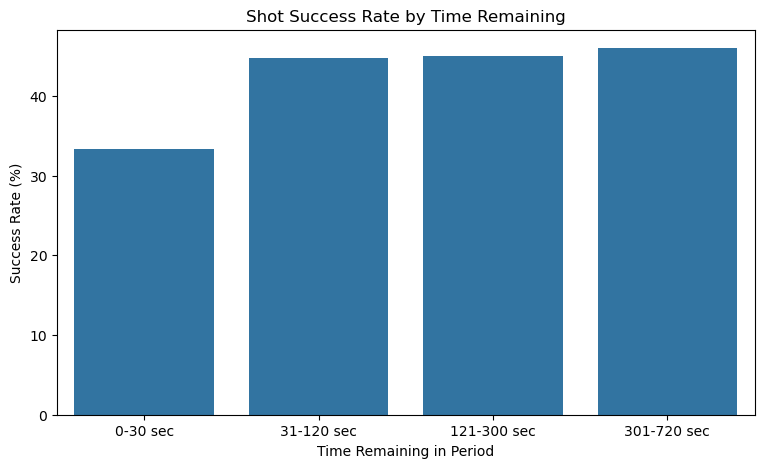

In [269]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=time_success,
    x="time_remaining_group",
    y="success_rate"
)

plt.title("Shot Success Rate by Time Remaining")
plt.xlabel("Time Remaining in Period")
plt.ylabel("Success Rate (%)")

plt.show()

In [270]:
print(model_data["playoffs"].value_counts())

playoffs
0    21939
1     3758
Name: count, dtype: int64


In [271]:
playoff_success = (
    model_data.groupby("playoffs")["shot_made_flag"]
    .mean()
    .mul(100)
    .reset_index(name="success_rate")
)

playoff_success

,playoffs,success_rate
0,0,44.641962
1,1,44.465141


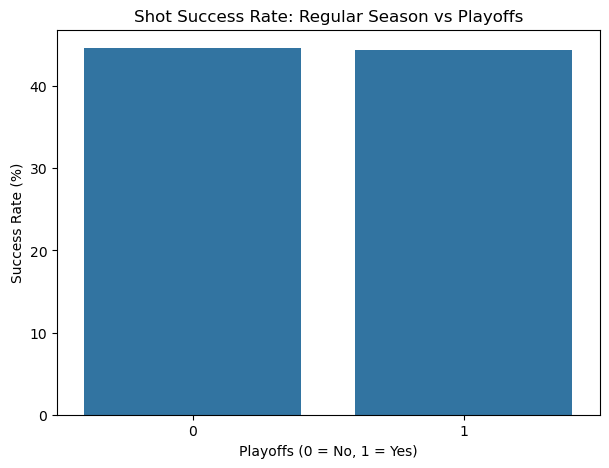

In [272]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=playoff_success,
    x="playoffs",
    y="success_rate"
)

plt.title("Shot Success Rate: Regular Season vs Playoffs")
plt.xlabel("Playoffs (0 = No, 1 = Yes)")
plt.ylabel("Success Rate (%)")

plt.show()

In [273]:
season_success = (
    model_data.groupby("season")["shot_made_flag"]
    .agg(["count", "mean"])
)

season_success["success_rate"] = season_success["mean"] * 100

season_success

,count,mean,success_rate
season,,,
1996-97,383,0.422977,42.297650
1997-98,810,0.430864,43.086420
1998-99,765,0.458824,45.882353
1999-00,1312,0.460366,46.036585
2000-01,1575,0.466667,46.666667
2001-02,1708,0.458431,45.843091
2002-03,1852,0.436285,43.628510
2003-04,1371,0.433260,43.326039
2004-05,1127,0.436557,43.655723


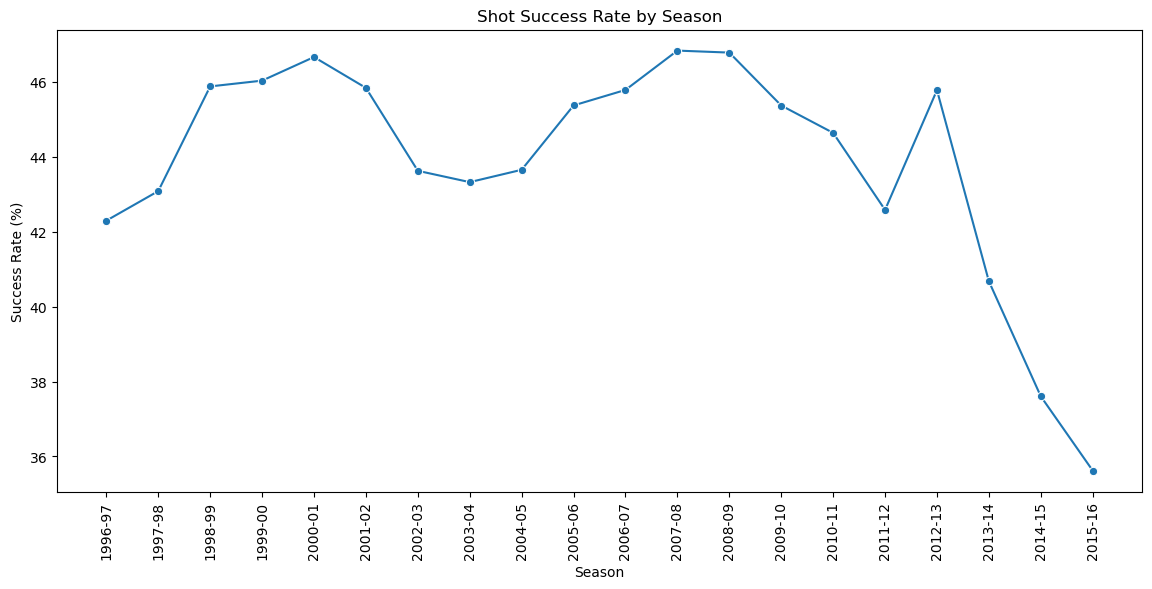

In [274]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=season_success.reset_index(),
    x="season",
    y="success_rate",
    marker="o"
)

plt.title("Shot Success Rate by Season")
plt.xlabel("Season")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=90)

plt.show()

In [275]:
opponent_analysis = (
    model_data.groupby("opponent")["shot_made_flag"]
    .agg(["count", "mean"])
)

opponent_analysis["success_rate"] = opponent_analysis["mean"] * 100

opponent_analysis = opponent_analysis.sort_values(
    "count",
    ascending=False
)

opponent_analysis.head(10)

,count,mean,success_rate
opponent,,,
SAS,1638,0.436508,43.650794
PHX,1535,0.464495,46.449511
HOU,1399,0.434596,43.459614
SAC,1397,0.465283,46.528275
DEN,1352,0.457840,45.784024
POR,1292,0.465170,46.517028
UTA,1238,0.444265,44.426494
MIN,1219,0.444627,44.462674
GSW,1143,0.464567,46.456693


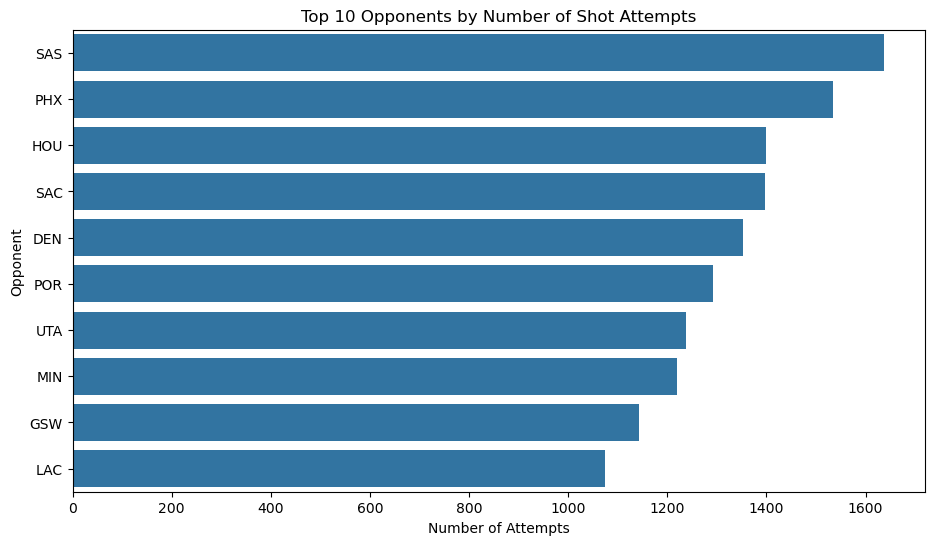

In [276]:
top_opponents = opponent_analysis.head(10).reset_index()

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_opponents,
    x="count",
    y="opponent"
)

plt.title("Top 10 Opponents by Number of Shot Attempts")
plt.xlabel("Number of Attempts")
plt.ylabel("Opponent")

plt.show()

In [277]:
numerical_features = [
    "loc_x",
    "loc_y",
    "minutes_remaining",
    "seconds_remaining",
    "period",
    "playoffs",
    "shot_distance",
    "seconds_remaining_in_period",
    "shot_made_flag"
]

correlation_matrix = model_data[numerical_features].corr()

correlation_matrix

,loc_x,loc_y,minutes_remaining,seconds_remaining,period,playoffs,shot_distance,seconds_remaining_in_period,shot_made_flag
loc_x,1.000000,-0.017578,0.006624,0.001512,-0.030059,-0.007751,0.022307,0.006714,-0.000848
loc_y,-0.017578,1.000000,-0.077399,-0.057766,0.039737,0.000857,0.818124,-0.081826,-0.148070
minutes_remaining,0.006624,-0.077399,1.000000,0.024232,-0.047021,0.009583,-0.064159,0.996458,0.028342
seconds_remaining,0.001512,-0.057766,0.024232,1.000000,0.007153,-0.005951,-0.055875,0.108218,0.030804
period,-0.030059,0.039737,-0.047021,0.007153,1.000000,0.003905,0.047311,-0.046157,-0.032152
playoffs,-0.007751,0.000857,0.009583,-0.005951,0.003905,1.000000,-0.007751,0.009029,-0.001257
shot_distance,0.022307,0.818124,-0.064159,-0.055875,0.047311,-0.007751,1.000000,-0.068501,-0.198242
seconds_remaining_in_period,0.006714,-0.081826,0.996458,0.108218,-0.046157,0.009029,-0.068501,1.000000,0.030775
shot_made_flag,-0.000848,-0.148070,0.028342,0.030804,-0.032152,-0.001257,-0.198242,0.030775,1.000000


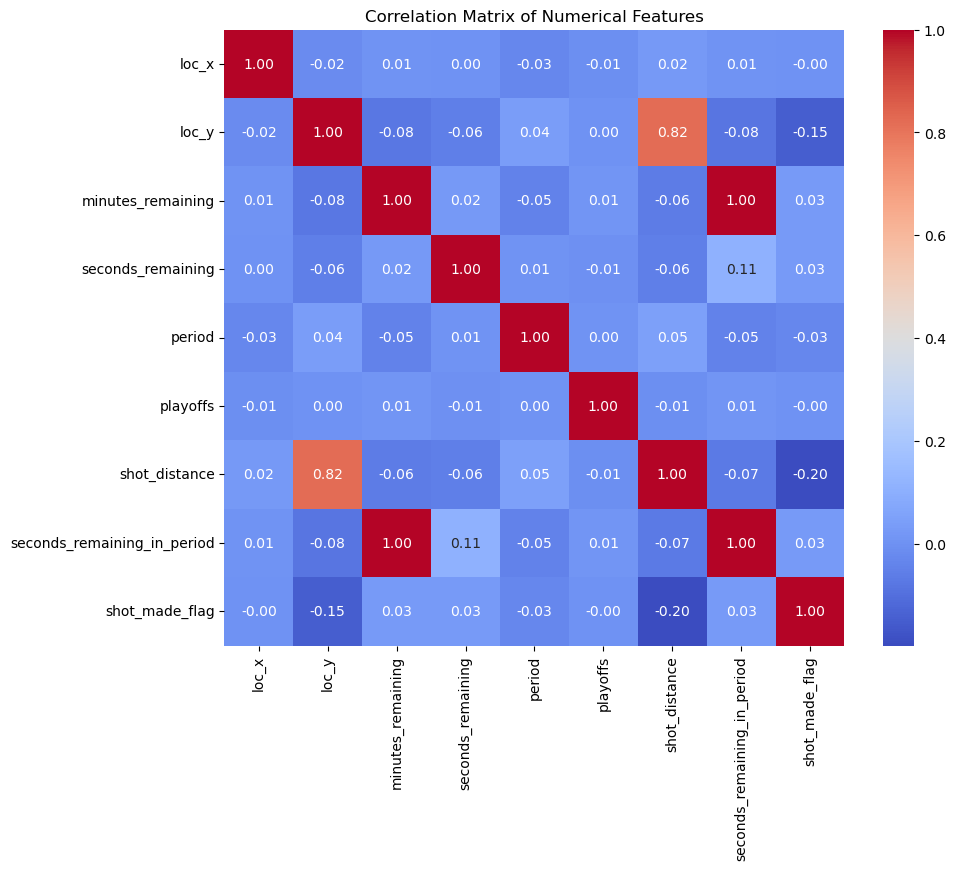

In [278]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [279]:
categorical_columns = model_data.select_dtypes(
    include=["object"]
).columns

cardinality = pd.DataFrame({
    "Column": categorical_columns,
    "Unique_Values": [
        model_data[col].nunique()
        for col in categorical_columns
    ]
})

cardinality = cardinality.sort_values(
    "Unique_Values",
    ascending=False
)

cardinality

,Column,Unique_Values
8,game_date,1558
9,matchup,74
0,action_type,55
10,opponent,33
2,season,20
5,shot_zone_basic,7
1,combined_shot_type,6
4,shot_zone_area,6
6,shot_zone_range,5
3,shot_type,2


In [280]:
constant_columns = [
    col
    for col in model_data.columns
    if model_data[col].nunique(dropna=False) == 1
]

print("Constant Columns:")
print(constant_columns)

Constant Columns:
['team_id', 'team_name']


In [281]:
identifier_columns = [
    "shot_id",
    "game_id",
    "game_event_id",
    "team_id"
]

for col in identifier_columns:
    print(
        col,
        "-> Unique Values:",
        model_data[col].nunique()
    )

shot_id -> Unique Values: 25697
game_id -> Unique Values: 1558
game_event_id -> Unique Values: 618
team_id -> Unique Values: 1


## Exploratory Data Analysis Summary

The exploratory data analysis provided several important insights into the NBA
shot-selection dataset.

The target variable represents whether a shot was made or missed, with both
classes containing a substantial number of observations. Therefore, Accuracy,
Precision, Recall and F1-score will be considered during model evaluation.

Shot characteristics such as `combined_shot_type`, `action_type`, `shot_type`,
`shot_distance`, `shot_zone_basic`, `shot_zone_area` and `shot_zone_range`
provide information about the type, difficulty and location of each shot.

The spatial variables `loc_x` and `loc_y` describe the location from which the
shot was attempted and may contain useful predictive information.

Game-context variables such as `period`, time remaining, `playoffs`, `season`
and `opponent` provide additional information about the circumstances surrounding
each shot.

A new feature, `seconds_remaining_in_period`, was created by combining
`minutes_remaining` and `seconds_remaining` into a single time measurement.

The EDA also identified several important preprocessing considerations.
Identifier columns should not automatically be treated as predictive numerical
features, constant columns provide no discriminatory information, and categorical
variables require appropriate encoding before model training.

These findings will guide the feature engineering, feature selection and
preprocessing stages of the project.

## Data Preprocessing and Feature Engineering

After completing Exploratory Data Analysis, the next step is to prepare the
dataset for machine learning.

Although the dataset is already structured, not every original column should
be directly provided to the model. Some variables are identifiers, some contain
redundant information, some are categorical, and some can be transformed into
more meaningful features.

The major preprocessing steps performed in this project are:

1. Separate rows with known and unknown target values
2. Convert the target variable into integer format
3. Create meaningful time-related features
4. Extract useful information from the game date
5. Remove identifier and constant columns
6. Remove redundant features
7. Separate features and target
8. Perform a stratified train-test split
9. Encode categorical variables
10. Scale numerical features where required

These steps help create a clean and suitable dataset for machine learning.

In [282]:
# Keep rows where the target value is available
model_data = df[df["shot_made_flag"].notnull()].copy()

# Keep unknown-target rows separately for future prediction
unknown_shots = df[df["shot_made_flag"].isnull()].copy()

# Convert target into integer
model_data["shot_made_flag"] = model_data["shot_made_flag"].astype(int)

print("Modeling Data Shape:", model_data.shape)
print("Unknown Shots Shape:", unknown_shots.shape)

Modeling Data Shape: (25697, 25)
Unknown Shots Shape: (5000, 25)


In [283]:
model_data["seconds_remaining_in_period"] = (
    model_data["minutes_remaining"] * 60
    + model_data["seconds_remaining"]
)

In [284]:
unknown_shots["seconds_remaining_in_period"] = (
    unknown_shots["minutes_remaining"] * 60
    + unknown_shots["seconds_remaining"]
)

In [285]:
model_data["is_clutch"] = (
    model_data["seconds_remaining_in_period"] <= 30
).astype(int)

unknown_shots["is_clutch"] = (
    unknown_shots["seconds_remaining_in_period"] <= 30
).astype(int)

In [286]:
print(model_data["game_date"].dtype)

object


In [287]:
model_data["game_date"] = pd.to_datetime(
    model_data["game_date"]
)

unknown_shots["game_date"] = pd.to_datetime(
    unknown_shots["game_date"]
)

In [288]:
model_data["game_year"] = model_data["game_date"].dt.year
model_data["game_month"] = model_data["game_date"].dt.month

unknown_shots["game_year"] = unknown_shots["game_date"].dt.year
unknown_shots["game_month"] = unknown_shots["game_date"].dt.month

In [289]:
model_data[
    ["game_date", "game_year", "game_month"]
].head()

,game_date,game_year,game_month
1,2000-10-31,2000,10
2,2000-10-31,2000,10
3,2000-10-31,2000,10
4,2000-10-31,2000,10
5,2000-10-31,2000,10


In [290]:
constant_columns = [
    col for col in model_data.columns
    if model_data[col].nunique(dropna=False) == 1
]

print("Constant Columns:")
print(constant_columns)

Constant Columns:
['team_id', 'team_name']


In [291]:
columns_to_drop = [
    "shot_id",
    "game_id",
    "game_event_id",
    "team_id",
    "team_name",
    "game_date"
]

In [292]:
model_data = model_data.drop(
    columns=columns_to_drop,
    errors="ignore"
)

unknown_shots = unknown_shots.drop(
    columns=columns_to_drop,
    errors="ignore"
)

In [293]:
model_data.drop(
    columns=[
        "minutes_remaining",
        "seconds_remaining"
    ],
    inplace=True,
    errors="ignore"
)

unknown_shots.drop(
    columns=[
        "minutes_remaining",
        "seconds_remaining"
    ],
    inplace=True,
    errors="ignore"
)

In [294]:
location_corr = model_data[
    ["loc_x", "loc_y", "lat", "lon", "shot_distance"]
].corr()

location_corr

,loc_x,loc_y,lat,lon,shot_distance
loc_x,1.000000,-0.017578,0.017578,1.000000,0.022307
loc_y,-0.017578,1.000000,-1.000000,-0.017578,0.818124
lat,0.017578,-1.000000,1.000000,0.017578,-0.818124
lon,1.000000,-0.017578,0.017578,1.000000,0.022307
shot_distance,0.022307,0.818124,-0.818124,0.022307,1.000000


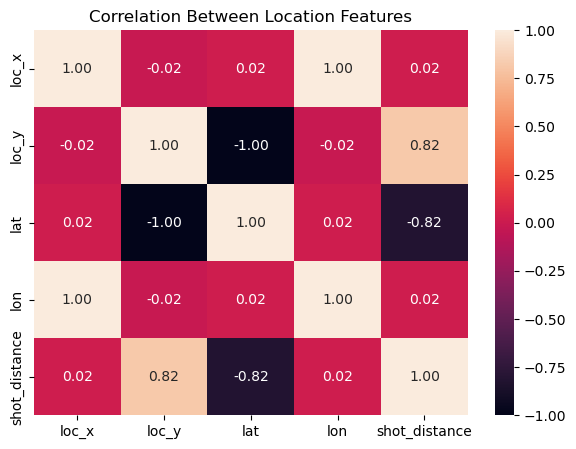

In [295]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    location_corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Location Features")

plt.show()

In [296]:
model_data.drop(
    columns=["lat", "lon"],
    inplace=True,
    errors="ignore"
)

unknown_shots.drop(
    columns=["lat", "lon"],
    inplace=True,
    errors="ignore"
)

In [297]:
model_data["is_home"] = (
    model_data["matchup"].str.contains("vs.")
).astype(int)

unknown_shots["is_home"] = (
    unknown_shots["matchup"].str.contains("vs.")
).astype(int)

In [298]:
model_data.drop(
    columns=["matchup"],
    inplace=True,
    errors="ignore"
)

unknown_shots.drop(
    columns=["matchup"],
    inplace=True,
    errors="ignore"
)

## Check the Dataset After Feature Engineering

In [299]:
print("Dataset Shape After Feature Engineering:")
print(model_data.shape)

print("\nRemaining Columns:")
print(model_data.columns.tolist())

Dataset Shape After Feature Engineering:
(25697, 19)

Remaining Columns:
['action_type', 'combined_shot_type', 'loc_x', 'loc_y', 'period', 'playoffs', 'season', 'shot_distance', 'shot_made_flag', 'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'opponent', 'seconds_remaining_in_period', 'is_clutch', 'game_year', 'game_month', 'is_home']


In [300]:
model_data.head()

,action_type,combined_shot_type,loc_x,loc_y,period,playoffs,season,shot_distance,shot_made_flag,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,opponent,seconds_remaining_in_period,is_clutch,game_year,game_month,is_home
1,Jump Shot,Jump Shot,-157,0,1,0,2000-01,15,0,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,POR,622,0,2000,10,0
2,Jump Shot,Jump Shot,-101,135,1,0,2000-01,16,1,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,POR,465,0,2000,10,0
3,Jump Shot,Jump Shot,138,175,1,0,2000-01,22,0,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,POR,412,0,2000,10,0
4,Driving Dunk Shot,Dunk,0,0,2,0,2000-01,0,1,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,POR,379,0,2000,10,0
5,Jump Shot,Jump Shot,-145,-11,3,0,2000-01,14,0,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,POR,572,0,2000,10,0


In [301]:
missing = model_data.isnull().sum()

print(
    missing[missing > 0]
)

Series([], dtype: int64)


In [302]:
X = model_data.drop(
    columns=["shot_made_flag"]
)

y = model_data["shot_made_flag"]

In [303]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

X Shape: (25697, 18)
y Shape: (25697,)

Target Distribution:
shot_made_flag
0    14232
1    11465
Name: count, dtype: int64


## Identify Numerical and Categorical Columns

In [304]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['loc_x', 'loc_y', 'period', 'playoffs', 'shot_distance', 'seconds_remaining_in_period', 'is_clutch', 'game_year', 'game_month', 'is_home']

Categorical Features:
['action_type', 'combined_shot_type', 'season', 'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'opponent']


Very Important: Split Before Fitting Preprocessing

We should split the dataset before fitting the encoder and scaler.

Why?

Because preprocessing should learn only from the training dataset.

Otherwise, information about the test dataset can influence preprocessing, which is called data leakage.

## Stratified Train-Test Split

In [305]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [306]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Target Percentage:")
print(
    y_train.value_counts(normalize=True).round(4)
)

print("\nTesting Target Percentage:")
print(
    y_test.value_counts(normalize=True).round(4)
)

Training Shape: (20557, 18)
Testing Shape: (5140, 18)

Training Target Percentage:
shot_made_flag
0    0.5538
1    0.4462
Name: proportion, dtype: float64

Testing Target Percentage:
shot_made_flag
0    0.5539
1    0.4461
Name: proportion, dtype: float64


## Observation

A stratified 80:20 train-test split was performed.

Stratification ensures that the proportion of made and missed shots remains
approximately the same in both the training and testing datasets.

This provides a fairer evaluation of classification models.

## Build the Preprocessing Pipeline

In [307]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [308]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

In [309]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [310]:
print(
    "Processed Training Shape:",
    X_train_processed.shape
)

print(
    "Processed Testing Shape:",
    X_test_processed.shape
)

Processed Training Shape: (20557, 144)
Processed Testing Shape: (5140, 144)


In [311]:
feature_names = preprocessor.get_feature_names_out()

print("Total Features After Preprocessing:")
print(len(feature_names))

print("\nFirst 30 Features:")
print(feature_names[:30])

Total Features After Preprocessing:
144

First 30 Features:
['num__loc_x' 'num__loc_y' 'num__period' 'num__playoffs'
 'num__shot_distance' 'num__seconds_remaining_in_period' 'num__is_clutch'
 'num__game_year' 'num__game_month' 'num__is_home'
 'cat__action_type_Alley Oop Dunk Shot'
 'cat__action_type_Alley Oop Layup shot'
 'cat__action_type_Cutting Layup Shot'
 'cat__action_type_Driving Bank shot' 'cat__action_type_Driving Dunk Shot'
 'cat__action_type_Driving Finger Roll Layup Shot'
 'cat__action_type_Driving Finger Roll Shot'
 'cat__action_type_Driving Floating Bank Jump Shot'
 'cat__action_type_Driving Floating Jump Shot'
 'cat__action_type_Driving Hook Shot' 'cat__action_type_Driving Jump shot'
 'cat__action_type_Driving Layup Shot'
 'cat__action_type_Driving Reverse Layup Shot'
 'cat__action_type_Driving Slam Dunk Shot' 'cat__action_type_Dunk Shot'
 'cat__action_type_Fadeaway Bank shot'
 'cat__action_type_Fadeaway Jump Shot'
 'cat__action_type_Finger Roll Layup Shot'
 'cat__action_

In [312]:
print("Training Samples:", X_train_processed.shape[0])
print("Testing Samples:", X_test_processed.shape[0])

print(
    "Missing Target Values:",
    y_train.isnull().sum() + y_test.isnull().sum()
)

print(
    "Training Classes:",
    sorted(y_train.unique())
)

Training Samples: 20557
Testing Samples: 5140
Missing Target Values: 0
Training Classes: [0, 1]


## Preprocessing and Feature Engineering Summary

The NBA shot-selection dataset was successfully prepared for machine learning.

The following preprocessing steps were performed:

1. Rows with known and unknown `shot_made_flag` values were separated.
2. The target variable was converted into binary integer format.
3. Minutes and seconds remaining were combined into
   `seconds_remaining_in_period`.
4. An `is_clutch` feature was created for shots attempted during the final
   30 seconds of a period.
5. Year and month were extracted from `game_date`.
6. Identifier and constant/redundant variables were removed.
7. Redundant latitude and longitude variables were removed while retaining
   interpretable court coordinates.
8. Home/away information was extracted from `matchup` as `is_home`.
9. Input features and the target variable were separated.
10. An 80:20 stratified train-test split was performed.
11. Numerical variables were standardized using StandardScaler.
12. Categorical variables were transformed using One-Hot Encoding.
13. The preprocessing transformer was fitted only on training data to prevent
    data leakage.

The processed training and testing datasets are now ready for machine learning
model development.

## BASELINE MACHINE LEARNING MODELS

In [314]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [315]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Evaluation metrics
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    precision = precision_score(y_test, test_pred, zero_division=0)
    recall = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)

    # Print results
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Training Accuracy : {train_accuracy:.4f}")
    print(f"Testing Accuracy  : {test_accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-Score          : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, test_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

    # Return results
    return {
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

## Logistic Regression

Logistic Regression is a classification algorithm that estimates the probability of an observation belonging to a particular class

In [316]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_processed,
    y_train
)


LogisticRegression(max_iter=1000, random_state=42)

Logistic Regression
Training Accuracy : 0.6841
Testing Accuracy  : 0.6761
Precision         : 0.7178
Recall            : 0.4514
F1-Score          : 0.5542

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.86      0.75      2847
           1       0.72      0.45      0.55      2293

    accuracy                           0.68      5140
   macro avg       0.69      0.65      0.65      5140
weighted avg       0.69      0.68      0.66      5140



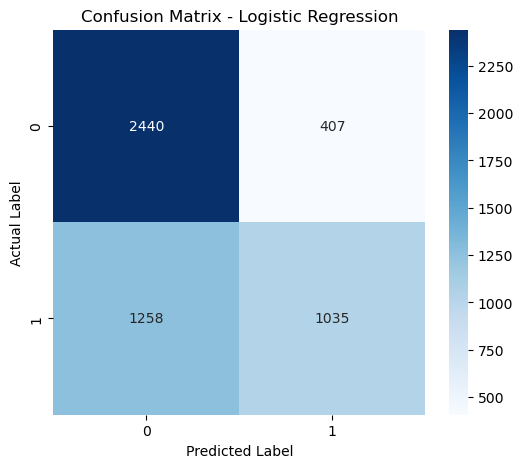

In [317]:
lr_results = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Decision Tree
A Decision Tree makes predictions through a sequence of decision rules.

In [318]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(random_state=42)

Decision Tree
Training Accuracy : 1.0000
Testing Accuracy  : 0.5819
Precision         : 0.5306
Recall            : 0.5447
F1-Score          : 0.5376

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62      2847
           1       0.53      0.54      0.54      2293

    accuracy                           0.58      5140
   macro avg       0.58      0.58      0.58      5140
weighted avg       0.58      0.58      0.58      5140



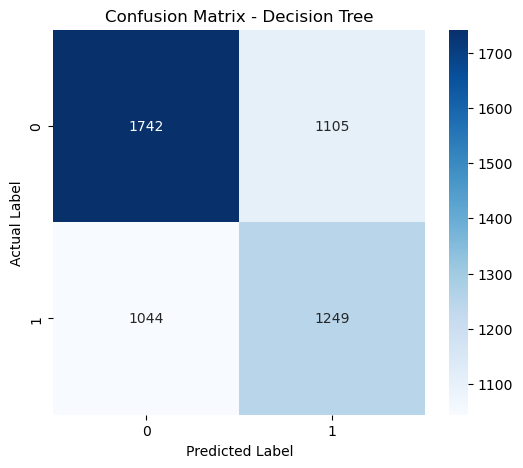

In [319]:
dt_results = evaluate_model(
    "Decision Tree",
    dt_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Random Forest

Random Forest is an ensemble algorithm consisting of many Decision Trees.

In [320]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

Random Forest
Training Accuracy : 1.0000
Testing Accuracy  : 0.6519
Precision         : 0.6495
Recall            : 0.4775
F1-Score          : 0.5504

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.79      0.72      2847
           1       0.65      0.48      0.55      2293

    accuracy                           0.65      5140
   macro avg       0.65      0.63      0.63      5140
weighted avg       0.65      0.65      0.64      5140



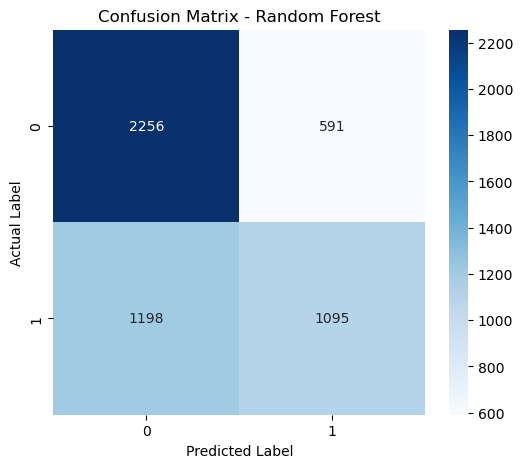

In [321]:
rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## K-Nearest Neighbors (KNN)

KNN classifies a new observation based on nearby training observations.

In [322]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

KNeighborsClassifier()

KNN
Training Accuracy : 0.7388
Testing Accuracy  : 0.6045
Precision         : 0.5703
Recall            : 0.4601
F1-Score          : 0.5093

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.72      0.67      2847
           1       0.57      0.46      0.51      2293

    accuracy                           0.60      5140
   macro avg       0.60      0.59      0.59      5140
weighted avg       0.60      0.60      0.60      5140



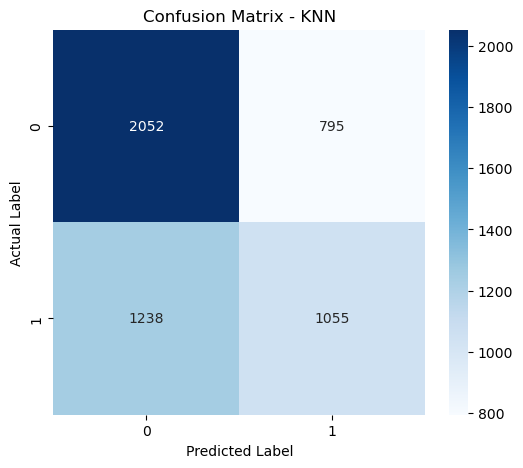

In [323]:
knn_results = evaluate_model(
    "KNN",
    knn_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Support Vector Machine (SVM)

SVM attempts to find a decision boundary that separates classes effectively.

For nonlinear classification, an RBF kernel can create more flexible boundaries.

In [445]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

svm_model.fit(
    X_train_processed,
    y_train
)

LinearSVC(max_iter=5000, random_state=42)

Linear SVM
Training Accuracy : 0.6843
Testing Accuracy  : 0.6763
Precision         : 0.7179
Recall            : 0.4518
F1-Score          : 0.5546

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.86      0.75      2847
           1       0.72      0.45      0.55      2293

    accuracy                           0.68      5140
   macro avg       0.69      0.65      0.65      5140
weighted avg       0.69      0.68      0.66      5140



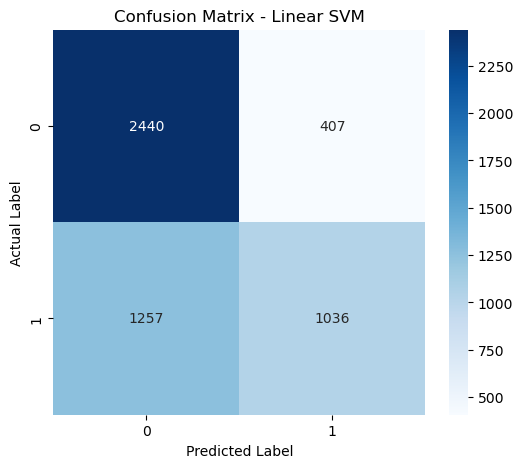

In [447]:
svm_results = evaluate_model(
    "Linear SVM",
    svm_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Create the Baseline Model Comparison Table

In [449]:
baseline_results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    knn_results,
    svm_results
])

baseline_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.684147,0.676070,0.717753,0.451374,0.554217
1,Decision Tree,1.000000,0.581907,0.530586,0.544701,0.537551
2,Random Forest,1.000000,0.651946,0.649466,0.477540,0.550390
3,KNN,0.738824,0.604475,0.570270,0.460096,0.509293
4,Linear SVM,0.684341,0.676265,0.717949,0.451810,0.554604


In [451]:
baseline_results_sorted = baseline_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

baseline_results_sorted

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.684341,0.676265,0.717949,0.451810,0.554604
1,Logistic Regression,0.684147,0.676070,0.717753,0.451374,0.554217
2,Random Forest,1.000000,0.651946,0.649466,0.477540,0.550390
3,Decision Tree,1.000000,0.581907,0.530586,0.544701,0.537551
4,KNN,0.738824,0.604475,0.570270,0.460096,0.509293


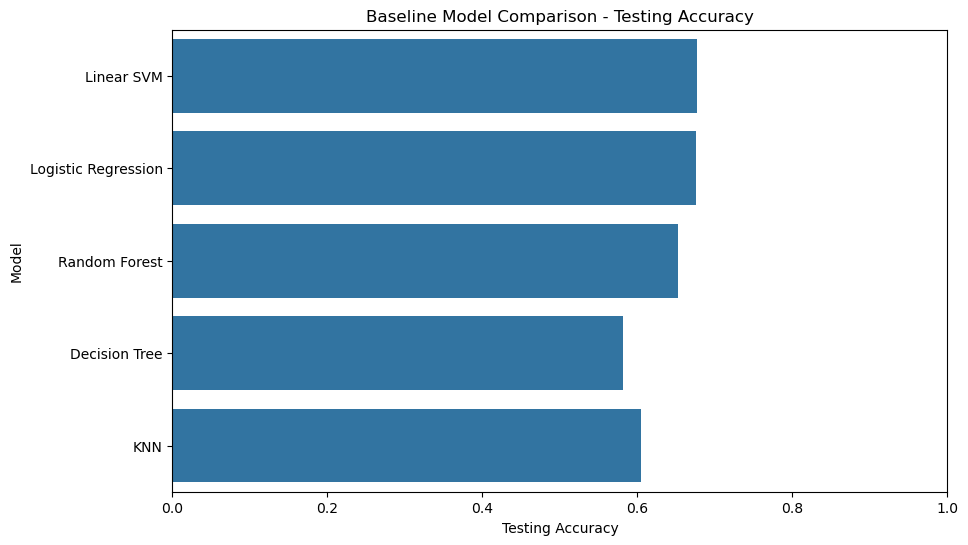

In [453]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_sorted,
    x="Testing Accuracy",
    y="Model"
)

plt.title("Baseline Model Comparison - Testing Accuracy")
plt.xlabel("Testing Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

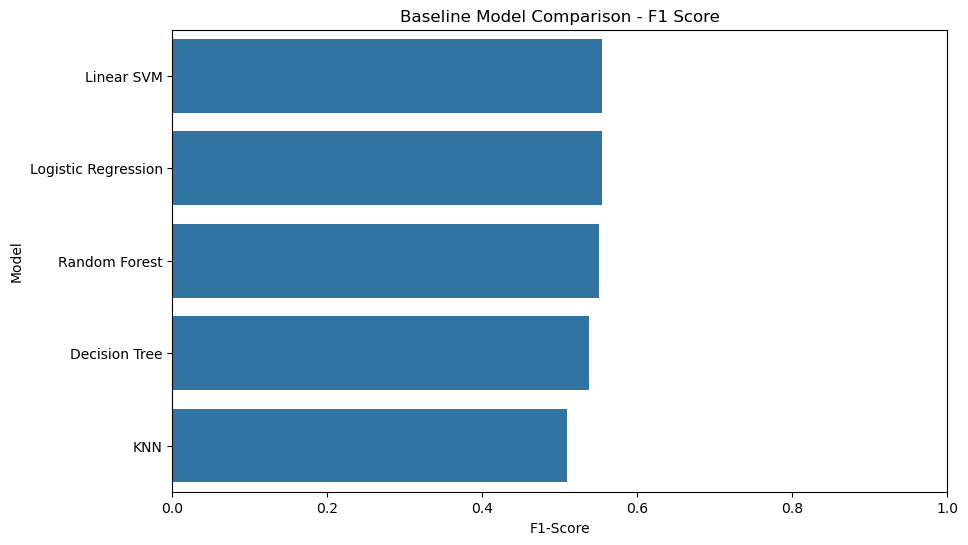

In [455]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_sorted,
    x="F1-Score",
    y="Model"
)

plt.title("Baseline Model Comparison - F1 Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

## Compare Training and Testing Accuracy

In [457]:
accuracy_comparison = baseline_results[
    [
        "Model",
        "Training Accuracy",
        "Testing Accuracy"
    ]
].copy()

accuracy_comparison

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.684147,0.676070
1,Decision Tree,1.000000,0.581907
2,Random Forest,1.000000,0.651946
3,KNN,0.738824,0.604475
4,Linear SVM,0.684341,0.676265


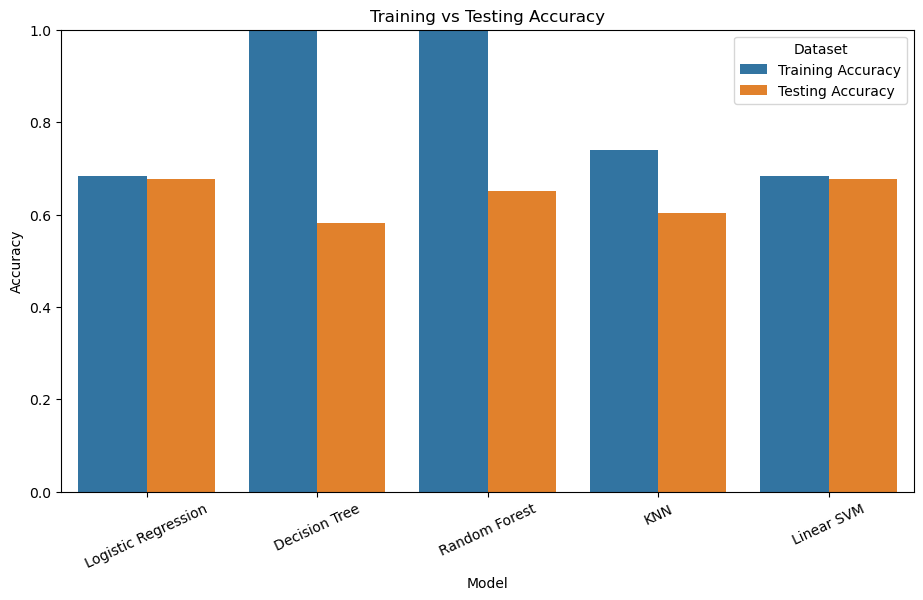

In [459]:
accuracy_long = accuracy_comparison.melt(
    id_vars="Model",
    var_name="Dataset",
    value_name="Accuracy"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=accuracy_long,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)

plt.title("Training vs Testing Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=25)
plt.ylim(0, 1)

plt.show()

## Baseline Model Evaluation Summary

Multiple machine learning classification algorithms were trained using the
preprocessed NBA shot-selection dataset.

The baseline models included Logistic Regression, Decision Tree, Random Forest,
K-Nearest Neighbors and Support Vector Machine.

Each model was evaluated using training accuracy, testing accuracy, precision,
recall and F1-score. Classification reports and confusion matrices were also
examined to understand class-specific performance.

Training and testing scores were compared to identify possible overfitting.
Models showing a large difference between training and testing performance
require additional regularization or hyperparameter tuning.

These baseline results provide an initial benchmark. A final production model
will not be selected until hyperparameter tuning, cross-validation and additional
model comparison have been completed.

## Hyperparameter Tuning and Model Optimization

The baseline models provide an initial understanding of model performance.
However, machine learning algorithms contain several hyperparameters that control
how the models learn from the data.

The objectives of this stage are:

1. Improve model generalization.
2. Reduce overfitting.
3. Improve F1-score and testing performance.
4. Evaluate model stability using cross-validation.
5. Compare baseline and optimized models.
6. Identify a suitable final classifier.

Because the project emphasizes both Accuracy and F1-score, F1-score is used as
an important criterion during model optimization.

## What is Hyperparameter Tuning?

- A parameter is learned automatically from data.

- A hyperparameter is something we configure before/during model training.

- Why RandomizedSearchCV?

GridSearchCV tests every possible parameter combination.

In [461]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

import numpy as np
import pandas as pd

In [463]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [465]:
lr_tuning = RandomizedSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_distributions=lr_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

lr_tuning.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=3,
                   estimator=LogisticRegression(max_iter=2000, random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100]},
                   random_state=42, scoring='f1')

In [467]:
print("Best Parameters:")
print(lr_tuning.best_params_)

print("\nBest Cross-Validation F1:")
print(lr_tuning.best_score_)

Best Parameters:
{'C': 0.01}

Best Cross-Validation F1:
0.56989614559274


In [469]:
best_lr = lr_tuning.best_estimator_

Tuned Logistic Regression
Training Accuracy : 0.6806
Testing Accuracy  : 0.6743
Precision         : 0.7038
Recall            : 0.4662
F1-Score          : 0.5609

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.84      0.74      2847
           1       0.70      0.47      0.56      2293

    accuracy                           0.67      5140
   macro avg       0.68      0.65      0.65      5140
weighted avg       0.68      0.67      0.66      5140



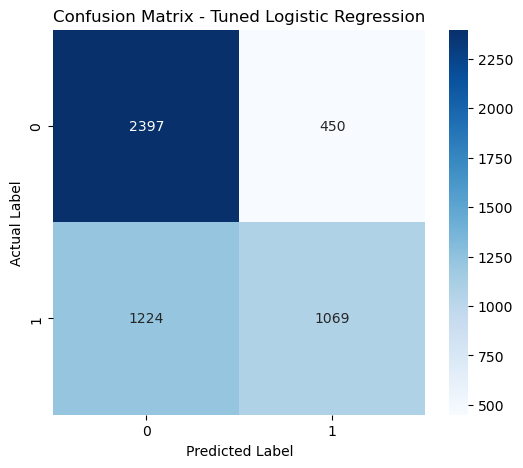

In [471]:
tuned_lr_results = evaluate_model(
    "Tuned Logistic Regression",
    best_lr,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

In [473]:
dt_params = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

In [475]:
dt_tuning = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_distributions=dt_params,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

dt_tuning.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10, 15, None],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 20]},
                   random_state=42, scoring='f1')

In [477]:
print("Best Parameters:")
print(dt_tuning.best_params_)

print("\nBest Cross-Validation F1:")
print(dt_tuning.best_score_)

Best Parameters:
{'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'criterion': 'gini'}

Best Cross-Validation F1:
0.5734733586392345


In [479]:
best_dt = dt_tuning.best_estimator_

Tuned Decision Tree
Training Accuracy : 0.6848
Testing Accuracy  : 0.6728
Precision         : 0.7006
Recall            : 0.4653
F1-Score          : 0.5592

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.84      0.74      2847
           1       0.70      0.47      0.56      2293

    accuracy                           0.67      5140
   macro avg       0.68      0.65      0.65      5140
weighted avg       0.68      0.67      0.66      5140



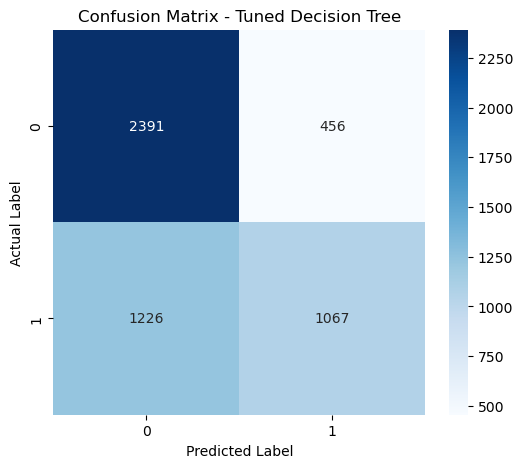

In [481]:
tuned_dt_results = evaluate_model(
    "Tuned Decision Tree",
    best_dt,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

In [483]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [486]:
rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_params,
    n_iter=12,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuning.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1', verbose=1)

In [488]:
print("Best Random Forest Parameters:")
print(rf_tuning.best_params_)

print("\nBest Cross-Validation F1:")
print(rf_tuning.best_score_)

Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best Cross-Validation F1:
0.5699436506366399


In [490]:
best_rf = rf_tuning.best_estimator_

Tuned Random Forest
Training Accuracy : 0.8182
Testing Accuracy  : 0.6757
Precision         : 0.7048
Recall            : 0.4697
F1-Score          : 0.5637

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.84      0.74      2847
           1       0.70      0.47      0.56      2293

    accuracy                           0.68      5140
   macro avg       0.68      0.66      0.65      5140
weighted avg       0.68      0.68      0.66      5140



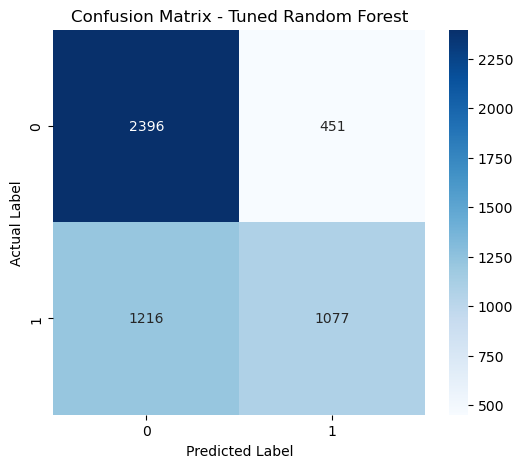

In [492]:
tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    best_rf,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

In [494]:
knn_params = {
    "n_neighbors": [5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

In [496]:
knn_tuning = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=knn_params,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

knn_tuning.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=3, estimator=KNeighborsClassifier(), n_iter=8, n_jobs=-1,
                   param_distributions={'n_neighbors': [5, 7, 9, 11, 15],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='f1')

In [498]:
print("Best KNN Parameters:")
print(knn_tuning.best_params_)

print("\nBest Cross-Validation F1:")
print(knn_tuning.best_score_)

Best KNN Parameters:
{'weights': 'uniform', 'p': 1, 'n_neighbors': 5}

Best Cross-Validation F1:
0.5185750638989143


In [500]:
best_knn = knn_tuning.best_estimator_

Tuned KNN
Training Accuracy : 0.7415
Testing Accuracy  : 0.6115
Precision         : 0.5797
Recall            : 0.4697
F1-Score          : 0.5189

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.67      2847
           1       0.58      0.47      0.52      2293

    accuracy                           0.61      5140
   macro avg       0.60      0.60      0.60      5140
weighted avg       0.61      0.61      0.60      5140



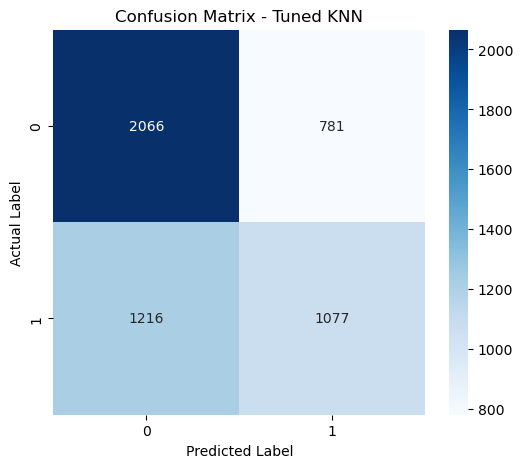

In [502]:
tuned_knn_results = evaluate_model(
    "Tuned KNN",
    best_knn,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

In [504]:
from sklearn.svm import LinearSVC

In [506]:
svm_params = {
    "C": [0.01, 0.1, 1, 10]
}


In [508]:
svm_tuning = RandomizedSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=5000
    ),
    param_distributions=svm_params,
    n_iter=4,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

svm_tuning.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=3, estimator=LinearSVC(max_iter=5000, random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10]},
                   random_state=42, scoring='f1')

In [510]:
print("Best Linear SVM Parameters:")
print(svm_tuning.best_params_)

print("\nBest Cross-Validation F1:")
print(svm_tuning.best_score_)

Best Linear SVM Parameters:
{'C': 0.01}

Best Cross-Validation F1:
0.5674947972991032


In [512]:
best_svm = svm_tuning.best_estimator_

Tuned Linear SVM
Training Accuracy : 0.6831
Testing Accuracy  : 0.6763
Precision         : 0.7150
Recall            : 0.4562
F1-Score          : 0.5570

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.74      2847
           1       0.71      0.46      0.56      2293

    accuracy                           0.68      5140
   macro avg       0.69      0.65      0.65      5140
weighted avg       0.69      0.68      0.66      5140



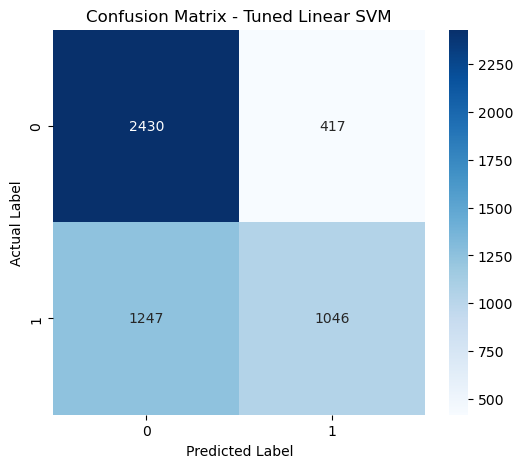

In [514]:
tuned_svm_results = evaluate_model(
    "Tuned Linear SVM",
    best_svm,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## What is XGBoost?

- XGBoost stands for Extreme Gradient Boosting.

- Random Forest builds many trees relatively independently and combines them.

- Boosting works differently:

In [516]:
import xgboost as xgb

print(xgb.__version__)

3.0.5


In [518]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

XGBoost
Training Accuracy : 0.6963
Testing Accuracy  : 0.6792
Precision         : 0.7224
Recall            : 0.4562
F1-Score          : 0.5592

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.86      0.75      2847
           1       0.72      0.46      0.56      2293

    accuracy                           0.68      5140
   macro avg       0.69      0.66      0.65      5140
weighted avg       0.69      0.68      0.66      5140



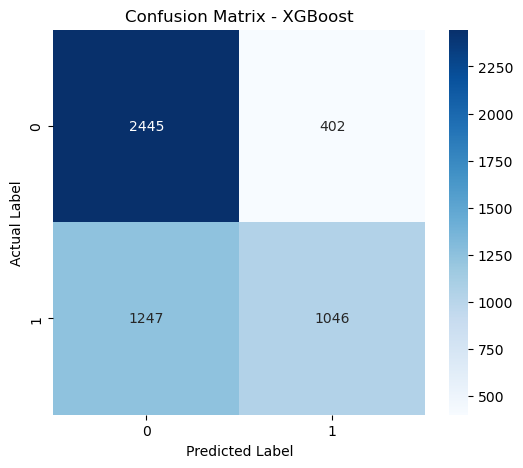

In [520]:
xgb_results = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

In [522]:
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [524]:
xgb_tuning = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_params,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_tuning.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [526]:
print("Best XGBoost Parameters:")
print(xgb_tuning.best_params_)

print("\nBest Cross-Validation F1:")
print(xgb_tuning.best_score_)

Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best Cross-Validation F1:
0.5698116170239546


In [528]:
best_xgb = xgb_tuning.best_estimator_

Tuned XGBoost
Training Accuracy : 0.6905
Testing Accuracy  : 0.6782
Precision         : 0.7172
Recall            : 0.4601
F1-Score          : 0.5606

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.75      2847
           1       0.72      0.46      0.56      2293

    accuracy                           0.68      5140
   macro avg       0.69      0.66      0.65      5140
weighted avg       0.69      0.68      0.66      5140



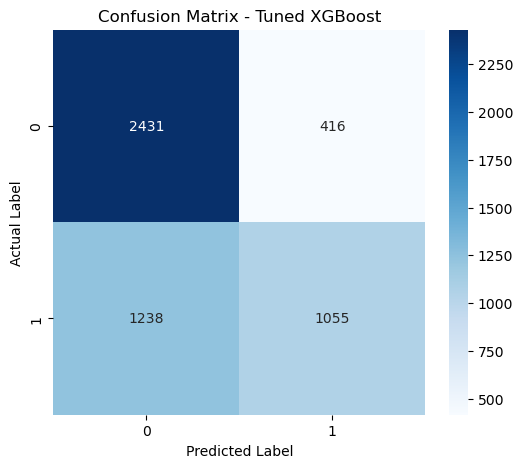

In [530]:
tuned_xgb_results = evaluate_model(
    "Tuned XGBoost",
    best_xgb,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Cross-Validate the Best Models
- Why Cross-Validation?

- A single train-test split gives us only one estimate of performance.

- Cross-validation repeatedly divides the training data into different sections.

- This gives a more reliable estimate of model stability.


In [532]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [534]:
cv_models = {
    "Tuned Logistic Regression": best_lr,
    "Tuned Random Forest": best_rf,
    "Tuned Linear SVM": best_svm,
    "Tuned XGBoost": best_xgb
}

In [536]:
cv_results = []

for model_name, model in cv_models.items():

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

    print(model_name)
    print("F1 Scores:", scores)
    print("Mean F1:", scores.mean())
    print("Standard Deviation:", scores.std())
    print("-" * 60)

Tuned Logistic Regression
F1 Scores: [0.57642487 0.57923853 0.56062581 0.57977676 0.55213505]
Mean F1: 0.5696402050947146
Standard Deviation: 0.011212481485037
------------------------------------------------------------
Tuned Random Forest
F1 Scores: [0.57244733 0.58129032 0.56957509 0.57915309 0.55064763]
Mean F1: 0.5706226914771004
Standard Deviation: 0.010862745096236612
------------------------------------------------------------
Tuned Linear SVM
F1 Scores: [0.57322314 0.57435558 0.55823161 0.58131028 0.54753107]
Mean F1: 0.5669303359456148
Standard Deviation: 0.012276121026783684
------------------------------------------------------------
Tuned XGBoost
F1 Scores: [0.57312644 0.57801185 0.56227525 0.58017299 0.55128633]
Mean F1: 0.5689745739525742
Standard Deviation: 0.010789527782700049
------------------------------------------------------------


In [538]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    "Mean CV F1",
    ascending=False
)

,Model,Mean CV F1,Std CV F1
1,Tuned Random Forest,0.570623,0.010863
0,Tuned Logistic Regression,0.569640,0.011212
3,Tuned XGBoost,0.568975,0.010790
2,Tuned Linear SVM,0.566930,0.012276


## Compare Tuned Models

In [540]:
tuned_results = pd.DataFrame([
    tuned_lr_results,
    tuned_dt_results,
    tuned_rf_results,
    tuned_knn_results,
    tuned_svm_results,
    tuned_xgb_results
])

tuned_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Tuned Logistic Regression,0.680595,0.674319,0.703752,0.466201,0.560860
1,Tuned Decision Tree,0.684828,0.672763,0.700591,0.465329,0.559224
2,Tuned Random Forest,0.818213,0.675681,0.704843,0.469690,0.563727
3,Tuned KNN,0.741499,0.611479,0.579656,0.469690,0.518911
4,Tuned Linear SVM,0.683125,0.676265,0.714969,0.456171,0.556976
5,Tuned XGBoost,0.690519,0.678210,0.717199,0.460096,0.560574


In [542]:
tuned_results = tuned_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

tuned_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Tuned Random Forest,0.818213,0.675681,0.704843,0.469690,0.563727
1,Tuned Logistic Regression,0.680595,0.674319,0.703752,0.466201,0.560860
2,Tuned XGBoost,0.690519,0.678210,0.717199,0.460096,0.560574
3,Tuned Decision Tree,0.684828,0.672763,0.700591,0.465329,0.559224
4,Tuned Linear SVM,0.683125,0.676265,0.714969,0.456171,0.556976
5,Tuned KNN,0.741499,0.611479,0.579656,0.469690,0.518911


## Visualize F1-Score

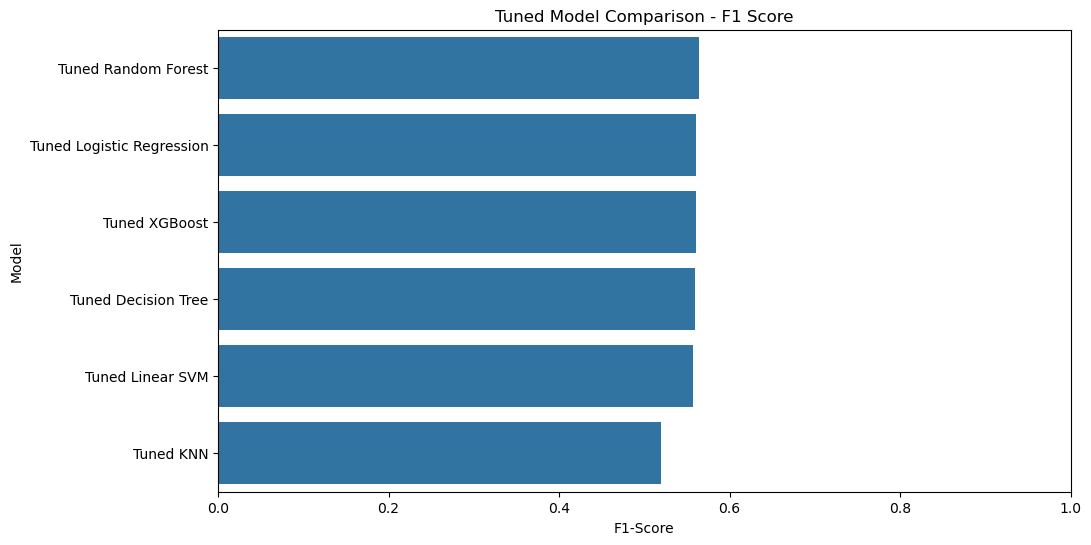

In [544]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=tuned_results,
    x="F1-Score",
    y="Model"
)

plt.title("Tuned Model Comparison - F1 Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

## Accuracy Comparison

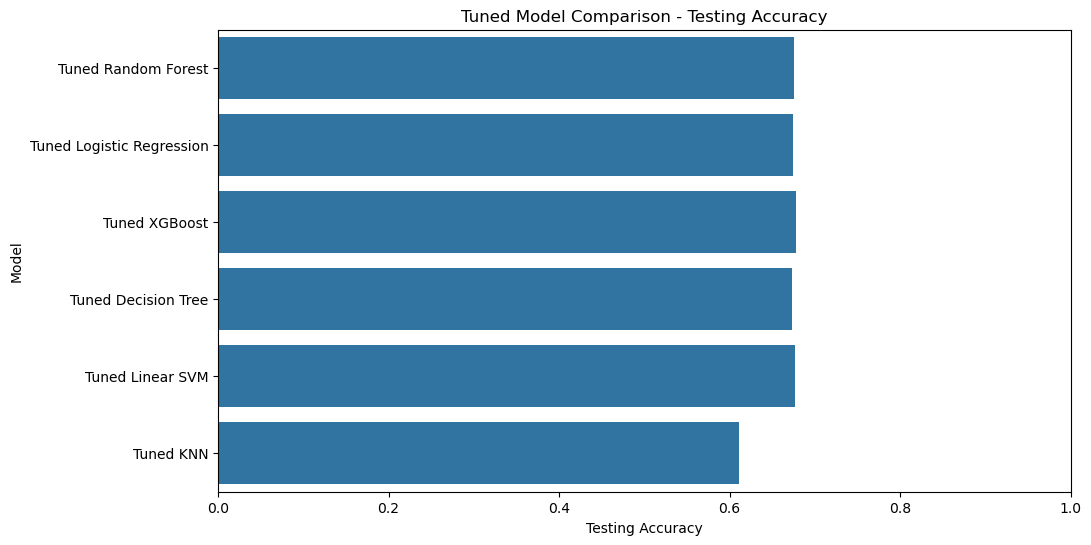

In [546]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=tuned_results,
    x="Testing Accuracy",
    y="Model"
)

plt.title("Tuned Model Comparison - Testing Accuracy")
plt.xlabel("Testing Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

## Detect Overfitting After Tuning

In [548]:
tuned_results["Accuracy Gap"] = (
    tuned_results["Training Accuracy"]
    - tuned_results["Testing Accuracy"]
)

tuned_results[
    [
        "Model",
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy Gap",
        "F1-Score"
    ]
]

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,F1-Score
0,Tuned Random Forest,0.818213,0.675681,0.142532,0.563727
1,Tuned Logistic Regression,0.680595,0.674319,0.006276,0.560860
2,Tuned XGBoost,0.690519,0.678210,0.012309,0.560574
3,Tuned Decision Tree,0.684828,0.672763,0.012065,0.559224
4,Tuned Linear SVM,0.683125,0.676265,0.006860,0.556976
5,Tuned KNN,0.741499,0.611479,0.130021,0.518911


In [550]:
baseline_results.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.6841,0.6761,0.7178,0.4514,0.5542
1,Decision Tree,1.0000,0.5819,0.5306,0.5447,0.5376
2,Random Forest,1.0000,0.6519,0.6495,0.4775,0.5504
3,KNN,0.7388,0.6045,0.5703,0.4601,0.5093
4,Linear SVM,0.6843,0.6763,0.7179,0.4518,0.5546


## Hyperparameter Tuning Observation

Hyperparameter tuning was performed to improve model performance and reduce
overfitting observed in the baseline models.

RandomizedSearchCV was preferred over an exhaustive GridSearchCV because it
provides a computationally efficient method of exploring multiple
hyperparameter combinations.

F1-score was used as an important optimization metric because the project
requires the classifier to provide strong classification performance rather
than relying only on overall accuracy.

Decision Tree and Random Forest parameters such as tree depth, minimum samples
per split and minimum samples per leaf were investigated to control model
complexity.

Regularization strength was tuned for Logistic Regression and Linear SVM.
The number of neighbors and weighting strategy were investigated for KNN.

XGBoost was also evaluated as a gradient-boosting classifier because it can
capture complex nonlinear relationships and interactions among shot
characteristics.

Finally, stratified cross-validation was used on the strongest candidate models
to evaluate their stability across multiple data splits.

The final model should be selected using testing performance, F1-score,
cross-validation performance and the difference between training and testing
scores rather than training accuracy alone.

## Final Model Comparison and Conclusion

After training and optimizing multiple machine learning classifiers, the final
stage of the project compares their performance and identifies the most suitable
model for NBA shot prediction.

The models are evaluated using:

- Training Accuracy
- Testing Accuracy
- Precision
- Recall
- F1-Score
- Cross-Validation Performance
- Generalization ability

The final model is selected based primarily on its ability to perform well on
unseen data rather than simply achieving the highest training accuracy.

## Baseline Model Comparison

In [552]:
baseline_sorted = baseline_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

baseline_sorted.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.6843,0.6763,0.7179,0.4518,0.5546
1,Logistic Regression,0.6841,0.6761,0.7178,0.4514,0.5542
2,Random Forest,1.0000,0.6519,0.6495,0.4775,0.5504
3,Decision Tree,1.0000,0.5819,0.5306,0.5447,0.5376
4,KNN,0.7388,0.6045,0.5703,0.4601,0.5093


In [554]:
tuned_results.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Accuracy Gap
0,Tuned Random Forest,0.8182,0.6757,0.7048,0.4697,0.5637,0.1425
1,Tuned Logistic Regression,0.6806,0.6743,0.7038,0.4662,0.5609,0.0063
2,Tuned XGBoost,0.6905,0.6782,0.7172,0.4601,0.5606,0.0123
3,Tuned Decision Tree,0.6848,0.6728,0.7006,0.4653,0.5592,0.0121
4,Tuned Linear SVM,0.6831,0.6763,0.7150,0.4562,0.5570,0.0069
5,Tuned KNN,0.7415,0.6115,0.5797,0.4697,0.5189,0.1300


## Tuned Model Comparison

In [556]:
tuned_sorted = tuned_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

tuned_sorted.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Accuracy Gap
0,Tuned Random Forest,0.8182,0.6757,0.7048,0.4697,0.5637,0.1425
1,Tuned Logistic Regression,0.6806,0.6743,0.7038,0.4662,0.5609,0.0063
2,Tuned XGBoost,0.6905,0.6782,0.7172,0.4601,0.5606,0.0123
3,Tuned Decision Tree,0.6848,0.6728,0.7006,0.4653,0.5592,0.0121
4,Tuned Linear SVM,0.6831,0.6763,0.7150,0.4562,0.5570,0.0069
5,Tuned KNN,0.7415,0.6115,0.5797,0.4697,0.5189,0.1300


## Baseline vs Tuned Models

In [558]:
baseline_compare = baseline_results.copy()

baseline_compare["Stage"] = "Baseline"

In [560]:
tuned_compare = tuned_results.copy()

tuned_compare["Stage"] = "Tuned"

In [562]:
final_comparison = pd.concat(
    [
        baseline_compare,
        tuned_compare
    ],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

final_comparison.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Stage,Accuracy Gap
0,Tuned Random Forest,0.8182,0.6757,0.7048,0.4697,0.5637,Tuned,0.1425
1,Tuned Logistic Regression,0.6806,0.6743,0.7038,0.4662,0.5609,Tuned,0.0063
2,Tuned XGBoost,0.6905,0.6782,0.7172,0.4601,0.5606,Tuned,0.0123
3,Tuned Decision Tree,0.6848,0.6728,0.7006,0.4653,0.5592,Tuned,0.0121
4,Tuned Linear SVM,0.6831,0.6763,0.7150,0.4562,0.5570,Tuned,0.0069
5,Linear SVM,0.6843,0.6763,0.7179,0.4518,0.5546,Baseline,NaN
6,Logistic Regression,0.6841,0.6761,0.7178,0.4514,0.5542,Baseline,NaN
7,Random Forest,1.0000,0.6519,0.6495,0.4775,0.5504,Baseline,NaN
8,Decision Tree,1.0000,0.5819,0.5306,0.5447,0.5376,Baseline,NaN
9,Tuned KNN,0.7415,0.6115,0.5797,0.4697,0.5189,Tuned,0.1300


## Final Performance Table

- For a cleaner final report:

In [564]:
final_performance = final_comparison[
    [
        "Model",
        "Stage",
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].copy()

final_performance.round(4)

,Model,Stage,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Tuned Random Forest,Tuned,0.8182,0.6757,0.7048,0.4697,0.5637
1,Tuned Logistic Regression,Tuned,0.6806,0.6743,0.7038,0.4662,0.5609
2,Tuned XGBoost,Tuned,0.6905,0.6782,0.7172,0.4601,0.5606
3,Tuned Decision Tree,Tuned,0.6848,0.6728,0.7006,0.4653,0.5592
4,Tuned Linear SVM,Tuned,0.6831,0.6763,0.7150,0.4562,0.5570
5,Linear SVM,Baseline,0.6843,0.6763,0.7179,0.4518,0.5546
6,Logistic Regression,Baseline,0.6841,0.6761,0.7178,0.4514,0.5542
7,Random Forest,Baseline,1.0000,0.6519,0.6495,0.4775,0.5504
8,Decision Tree,Baseline,1.0000,0.5819,0.5306,0.5447,0.5376
9,Tuned KNN,Tuned,0.7415,0.6115,0.5797,0.4697,0.5189


## Calculate Overfitting Gap
- A model may have excellent training accuracy but perform poorly on unseen data.

In [566]:
final_performance["Accuracy Gap"] = (
    final_performance["Training Accuracy"]
    - final_performance["Testing Accuracy"]
)

final_performance = final_performance.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

final_performance.round(4)

,Model,Stage,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Accuracy Gap
0,Tuned Random Forest,Tuned,0.8182,0.6757,0.7048,0.4697,0.5637,0.1425
1,Tuned Logistic Regression,Tuned,0.6806,0.6743,0.7038,0.4662,0.5609,0.0063
2,Tuned XGBoost,Tuned,0.6905,0.6782,0.7172,0.4601,0.5606,0.0123
3,Tuned Decision Tree,Tuned,0.6848,0.6728,0.7006,0.4653,0.5592,0.0121
4,Tuned Linear SVM,Tuned,0.6831,0.6763,0.7150,0.4562,0.5570,0.0069
5,Linear SVM,Baseline,0.6843,0.6763,0.7179,0.4518,0.5546,0.0081
6,Logistic Regression,Baseline,0.6841,0.6761,0.7178,0.4514,0.5542,0.0081
7,Random Forest,Baseline,1.0000,0.6519,0.6495,0.4775,0.5504,0.3481
8,Decision Tree,Baseline,1.0000,0.5819,0.5306,0.5447,0.5376,0.4181
9,Tuned KNN,Tuned,0.7415,0.6115,0.5797,0.4697,0.5189,0.1300


## Visualize Final F1-Scores

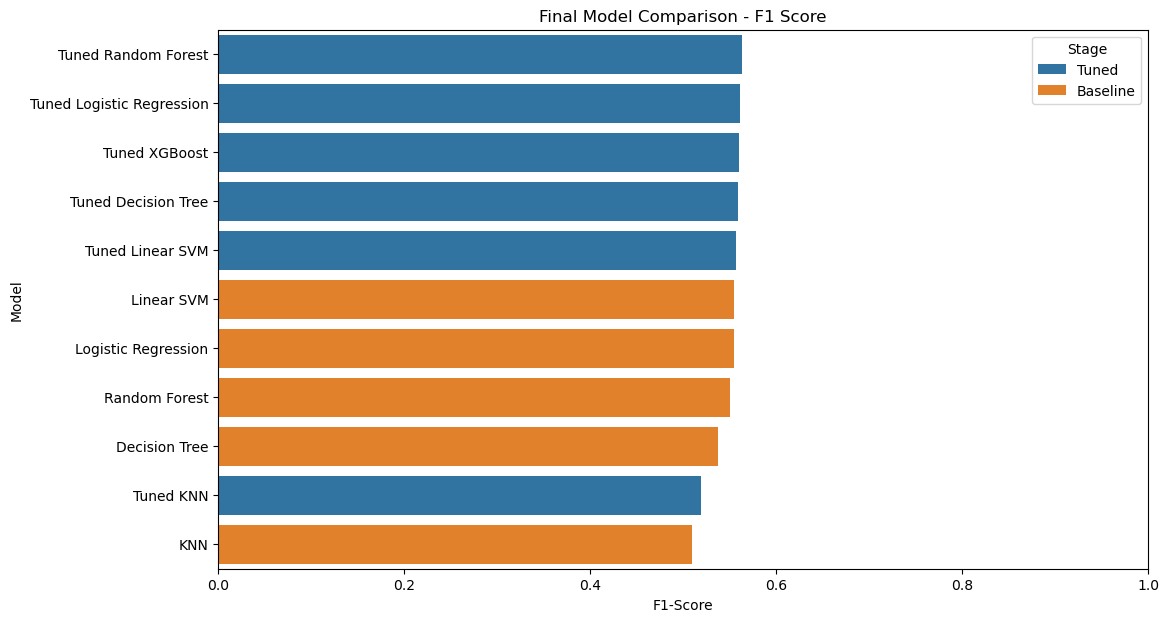

In [568]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=final_performance,
    x="F1-Score",
    y="Model",
    hue="Stage"
)

plt.title("Final Model Comparison - F1 Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

### Observation

The F1-score comparison shows the relative classification performance of the
baseline and optimized models.

Hyperparameter tuning improved or controlled the performance of several models.
The final model should be selected by considering F1-score together with testing
accuracy, cross-validation performance and the training-testing performance gap.

## Testing Accuracy Comparison

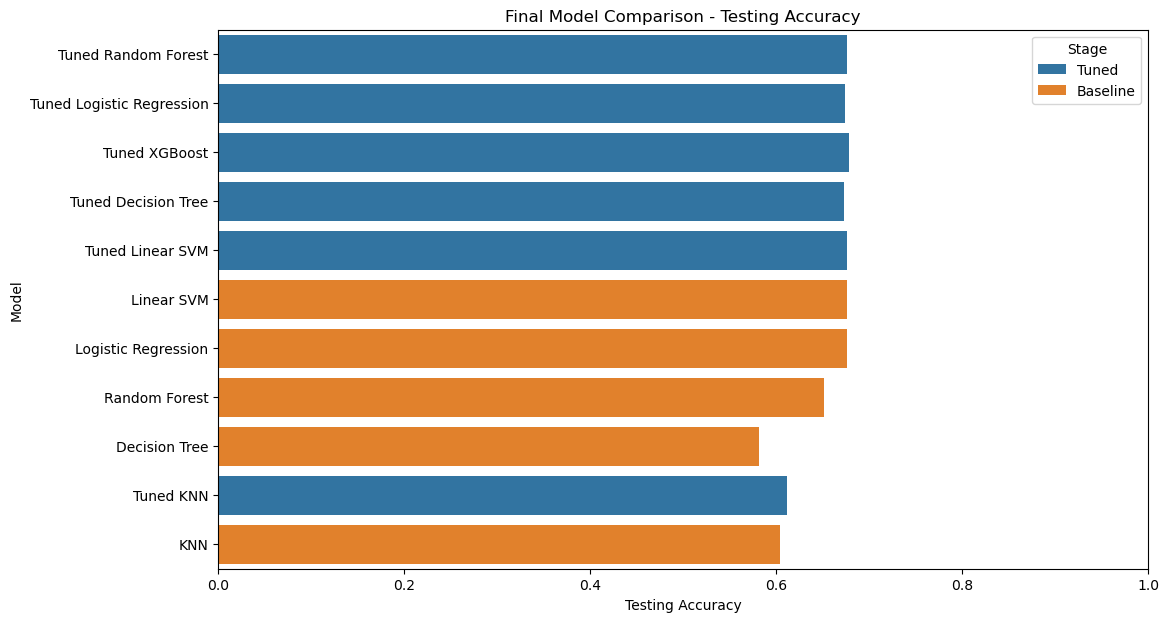

In [570]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=final_performance,
    x="Testing Accuracy",
    y="Model",
    hue="Stage"
)

plt.title("Final Model Comparison - Testing Accuracy")
plt.xlabel("Testing Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

## Find the Highest F1-Score Automatically

In [572]:
best_row = final_performance.loc[
    final_performance["F1-Score"].idxmax()
]

print("Best Model Based on Test F1-Score")
print("----------------------------------")
print("Model:", best_row["Model"])
print("Stage:", best_row["Stage"])
print(
    "Testing Accuracy:",
    round(best_row["Testing Accuracy"], 4)
)
print(
    "Precision:",
    round(best_row["Precision"], 4)
)
print(
    "Recall:",
    round(best_row["Recall"], 4)
)
print(
    "F1-Score:",
    round(best_row["F1-Score"], 4)
)
print(
    "Accuracy Gap:",
    round(best_row["Accuracy Gap"], 4)
)

Best Model Based on Test F1-Score
----------------------------------
Model: Tuned Random Forest
Stage: Tuned
Testing Accuracy: 0.6757
Precision: 0.7048
Recall: 0.4697
F1-Score: 0.5637
Accuracy Gap: 0.1425


## Cross-Validation Comparison

In [574]:
cv_results_df.sort_values(
    by="Mean CV F1",
    ascending=False
).reset_index(drop=True).round(4)

,Model,Mean CV F1,Std CV F1
0,Tuned Random Forest,0.5706,0.0109
1,Tuned Logistic Regression,0.5696,0.0112
2,Tuned XGBoost,0.5690,0.0108
3,Tuned Linear SVM,0.5669,0.0123


## Final Classification Report

In [578]:
final_pred = final_model.predict(
    X_test_processed
)

print("FINAL MODEL CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        final_pred,
        zero_division=0
    )
)

FINAL MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.66      0.85      0.75      2847
           1       0.72      0.46      0.56      2293

    accuracy                           0.68      5140
   macro avg       0.69      0.66      0.65      5140
weighted avg       0.69      0.68      0.66      5140



## Final Confusion Matrix

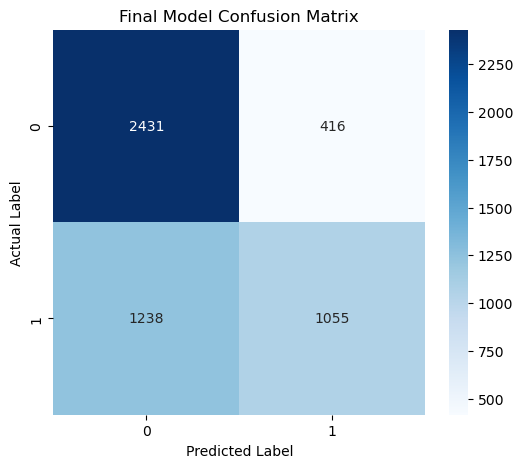

In [580]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [582]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(20)

,Feature,Importance
0,cat__action_type_Jump Shot,0.270218
1,cat__action_type_Layup Shot,0.112285
2,cat__combined_shot_type_Dunk,0.042198
3,cat__combined_shot_type_Layup,0.030649
4,cat__combined_shot_type_Tip Shot,0.019611
5,cat__action_type_Tip Shot,0.017807
6,cat__opponent_PHI,0.013776
7,cat__shot_zone_range_Less Than 8 ft.,0.013383
8,cat__action_type_Turnaround Jump Shot,0.012721
9,cat__action_type_Hook Shot,0.011627


## Plot Top 20 Features

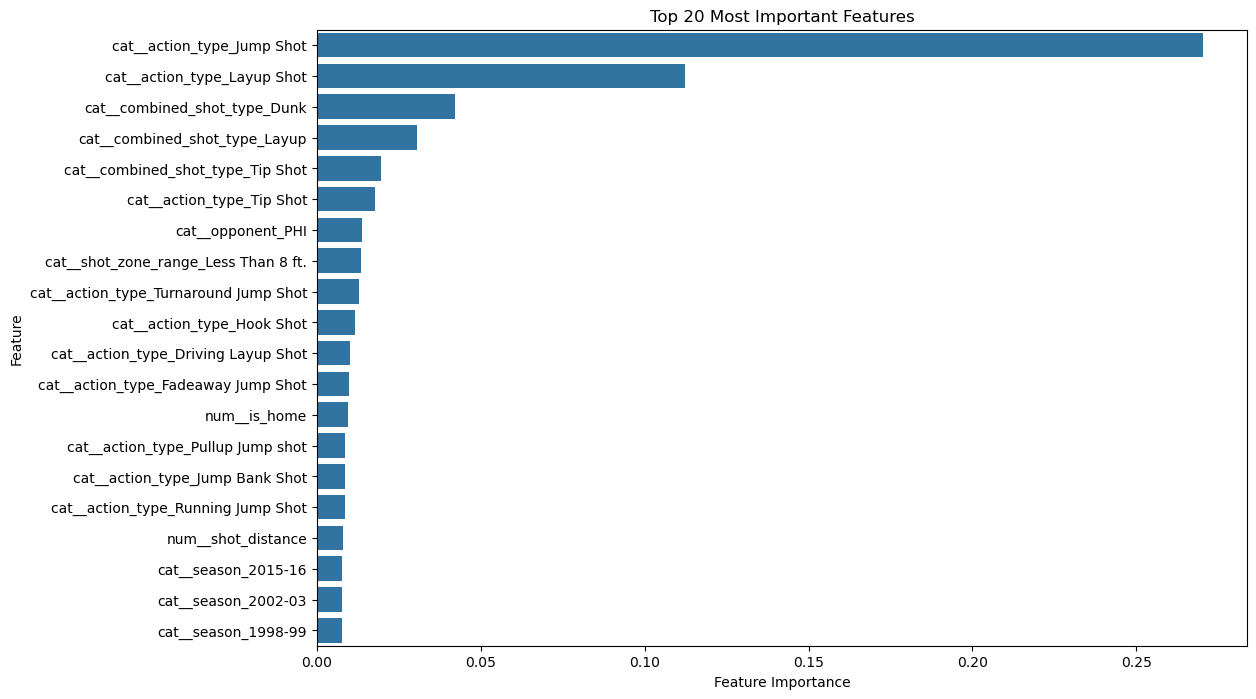

In [584]:
top_features = importance_df.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Basketball Strategy Insights

In [588]:
strategy_by_zone = (
    model_data.groupby("shot_zone_basic")
    ["shot_made_flag"]
    .agg(
        Attempts="count",
        Made="sum",
        Success_Rate="mean"
    )
    .reset_index()
)

strategy_by_zone["Success_Rate"] = (
    strategy_by_zone["Success_Rate"] * 100
)

strategy_by_zone = strategy_by_zone.sort_values(
    "Success_Rate",
    ascending=False
)

strategy_by_zone.round(2)

,shot_zone_basic,Attempts,Made,Success_Rate
5,Restricted Area,5932,3666,61.80
2,In The Paint (Non-RA),3880,1763,45.44
4,Mid-Range,10532,4279,40.63
3,Left Corner 3,240,89,37.08
6,Right Corner 3,333,113,33.93
0,Above the Break 3,4720,1554,32.92
1,Backcourt,60,1,1.67


## Strategy by Shot Type

In [625]:
strategy_by_shot = (
    model_data.groupby("combined_shot_type")
    ["shot_made_flag"]
    .agg(
        Attempts="count",
        Made="sum",
        Success_Rate="mean"
    )
    .reset_index()
)

strategy_by_shot["Success_Rate"] *= 100

strategy_by_shot = strategy_by_shot.sort_values(
    "Success_Rate",
    ascending=False
)

strategy_by_shot.round(2)

,combined_shot_type,Attempts,Made,Success_Rate
1,Dunk,1056,980,92.80
0,Bank Shot,120,95,79.17
4,Layup,4532,2561,56.51
2,Hook Shot,127,68,53.54
3,Jump Shot,19710,7708,39.11
5,Tip Shot,152,53,34.87


## Strategy by Distance

- Exact distances can be noisy, so group them into ranges.
- This is more meaningful for stakeholders than raw model metrics alone.

In [592]:
model_data["distance_group"] = pd.cut(
    model_data["shot_distance"],
    bins=[-1, 5, 10, 15, 20, 25, 30, np.inf],
    labels=[
        "0-5",
        "6-10",
        "11-15",
        "16-20",
        "21-25",
        "26-30",
        "30+"
    ]
)

distance_strategy = (
    model_data.groupby(
        "distance_group",
        observed=False
    )["shot_made_flag"]
    .agg(
        Attempts="count",
        Made="sum",
        Success_Rate="mean"
    )
    .reset_index()
)

distance_strategy["Success_Rate"] *= 100

distance_strategy.round(2)

,distance_group,Attempts,Made,Success_Rate
0,0-5,6693,4009,59.90
1,6-10,2844,1236,43.46
2,11-15,3898,1688,43.30
3,16-20,5709,2277,39.88
4,21-25,4629,1726,37.29
5,26-30,1759,523,29.73
6,30+,165,6,3.64


## Predict the 5,000 Unknown Shot Outcomes

In [594]:
unknown_X = unknown_shots.drop(
    columns=["shot_made_flag"],
    errors="ignore"
)

In [596]:
unknown_X = unknown_X[X.columns]

In [600]:
unknown_processed = preprocessor.transform(
    unknown_X
)

In [602]:
unknown_predictions = final_model.predict(
    unknown_processed
)

print("Number of Predictions:")
print(len(unknown_predictions))

print("\nFirst 20 Predictions:")
print(unknown_predictions[:20])

Number of Predictions:
5000

First 20 Predictions:
[0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1]


In [606]:
unknown_results = unknown_shots.copy()

unknown_results["predicted_shot_made_flag"] = (
    unknown_predictions
)

unknown_results[
    ["predicted_shot_made_flag"]
].head(10)

,predicted_shot_made_flag
0,0
7,0
16,1
19,1
32,0
33,0
34,1
35,1
36,1
37,0


In [608]:
prediction_counts = (
    unknown_results[
        "predicted_shot_made_flag"
    ]
    .value_counts()
    .sort_index()
)

prediction_counts

predicted_shot_made_flag
0    3510
1    1490
Name: count, dtype: int64

In [610]:
prediction_percentage = (
    unknown_results[
        "predicted_shot_made_flag"
    ]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

prediction_percentage.round(2)

predicted_shot_made_flag
0    70.2
1    29.8
Name: proportion, dtype: float64

In [612]:
prediction_output = pd.DataFrame({
    "shot_id": df.loc[
        df["shot_made_flag"].isnull(),
        "shot_id"
    ].values,

    "predicted_shot_made_flag":
        unknown_predictions
})

prediction_output.head()

,shot_id,predicted_shot_made_flag
0,1,0
1,8,0
2,17,1
3,20,1
4,33,0


In [614]:
prediction_output.to_csv(
    "NBA_Shot_Predictions.csv",
    index=False
)

### Challenges Faced

Several challenges were encountered during the development of the NBA Shot
Selection project.

### 1. Missing Target Values

The `shot_made_flag` column contained missing values. Since this variable is the
prediction target, these values could not be filled using ordinary imputation
methods. Rows with known outcomes were therefore used for model development,
while unknown outcomes were preserved for final prediction.

### 2. Categorical Variables

The dataset contained several categorical features such as action type, shot
type, opponent and shot zone. These variables required appropriate encoding
before they could be used by machine learning algorithms.

### 3. Redundant Variables

Several variables represented overlapping information, including court
coordinates, time variables and matchup information. Feature engineering and
feature selection were used to reduce unnecessary redundancy.

### 4. Identifier Variables

Variables such as shot ID, game ID and event ID primarily acted as identifiers
rather than direct descriptions of shooting circumstances. These required
careful treatment during feature selection.

### 5. Model Overfitting

Some flexible models, particularly unrestricted tree-based classifiers, can
achieve very high training performance while performing considerably worse on
unseen data. Hyperparameter tuning was therefore used to control model
complexity.

### 6. SVM Computational Cost

An RBF-kernel Support Vector Machine required considerable computation time on
the high-dimensional encoded dataset. LinearSVC was therefore used as a more
computationally efficient SVM baseline.

### 7. Model Selection

The highest training accuracy does not necessarily represent the best model.
Testing F1-score, testing accuracy, cross-validation performance and
generalization were considered when selecting the final classifier.

### Support Vector Machine

An RBF-kernel Support Vector Classifier was initially considered for the
classification problem. However, the preprocessing stage produced a
high-dimensional feature space after one-hot encoding the categorical variables.

Training an RBF SVM on this dataset was computationally expensive and required
considerable execution time.

Therefore, LinearSVC was used as a computationally efficient SVM alternative.
LinearSVC is suitable for relatively large and high-dimensional datasets and
allows the performance of a Support Vector Machine classifier to be included
in the baseline model comparison.

## Conclusion

The NBA Shot Selection project successfully applied machine learning techniques
to analyze and predict Kobe Bryant's field-goal outcomes.

The project began with data understanding and exploratory data analysis to
investigate shooting patterns related to shot type, distance, court location,
game period, time remaining, opponent, season and playoff status.

Feature engineering was performed to create more meaningful representations of
time, date and home/away information. Identifier, constant and redundant
variables were carefully handled before model development.

Multiple classification algorithms were evaluated, including Logistic
Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Linear Support
Vector Machine and XGBoost.

The models were compared using training accuracy, testing accuracy, precision,
recall and F1-score. Hyperparameter tuning and stratified cross-validation were
used to improve model performance and assess generalization.

The final classifier was selected based on its performance on unseen data rather
than training accuracy alone.

In addition to predictive modeling, the project generated basketball analytics
insights related to shooting distance, shot type, court zones and game context.
These findings demonstrate how data analytics and machine learning can support
more informed shot-selection and strategic analysis.

## Future Scope

The project can be extended in several directions:

1. Incorporate defender-distance and defensive-pressure information.
2. Include player movement and tracking data.
3. Include score difference and game situation.
4. Analyze shot probability using spatial court heatmaps.
5. Develop probability-based shot-quality scores instead of only binary predictions.
6. Compare additional boosting algorithms such as LightGBM and CatBoost.
7. Apply model explainability methods such as SHAP.
8. Deploy the final classifier using Streamlit or Flask.
9. Extend the analysis to multiple NBA players.
10. Build an interactive basketball analytics dashboard using Power BI or Tableau.